# Unsupervised Learning Trading Strategy

Unsupervised learning in trading involves using machine learning techniques to analyze financial data and disciver patterns, relationships, and structures within the data without any labeled or predefined target variable. Unlike supervised learning, where the model is trained to make predictions, unsupervised learning focuses on extracting insights from data. 

It is applied in trading as follows: 

- Clustering
- Dimensionality Reduction
- Anomaly Regime Detection
- Portfolio Optimization

### Breakdown

1. Download SP500 stocks prices data
2. Calculate different technical indicators and features for each stock
3. Aggregate on monthly level and filter for each month only top 150 most liquid stocks
4. Calculate monthly returns for different time horizons to add to features
5. For each month, fit a K-means clustering model to group similar assets based on their features
6. For each month, select assets based on the cluster and form a portfolio based on Efficient Frontier max sharpe ratio portfolio optimization
7. Visualize the portfolio returns and compare to SP500 returns

### Limitations

We are using the most recent stocks list, so we might have a survivorship data. In any algorithm ran there is a need of dealing with survivorship free data to not interfere with measuring future risks that the algorithm could face and biasing our results. 

In [150]:
!pip install numpy
!pip install pandas 
#!pip install pandas-ta
!pip install ta-lib
!pip install matplotlib
!pip install statsmodels
!pip install pandas_datareader
!pip install datetime
!pip install yfinance
!pip install scikit-learn
!pip install PyPortfolioOpt

python(90145) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(90147) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(90148) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(90149) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(90150) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(90151) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(90152) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(90153) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(90154) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(90155) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


## 1. Download/Load SP500 Stocks Prices Data

In [151]:
from statsmodels.regression.rolling import RollingOLS
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import statsmodels.api as sm
import talib
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf
#import pandas_ta
import requests
from bs4 import BeautifulSoup
import warnings
warnings.filterwarnings('ignore')

In [192]:
# Add headers to mimic a browser request
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

# Make a request with headers
response = requests.get('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies', headers=headers)


soup = BeautifulSoup(response.text, 'html.parser')
    
# Find the table and convert to DataFrame
tables = pd.read_html(response.text)
    
# Usually the first table is what we want
sp500 = tables[0]
    
# Display the table
sp500.head()


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [193]:
sp500['Symbol'] = sp500['Symbol'].str.replace('.', '-')
symbols_list = sp500['Symbol'].unique().tolist()
symbols_list #not survivorship biased free

['MMM',
 'AOS',
 'ABT',
 'ABBV',
 'ACN',
 'ADBE',
 'AMD',
 'AES',
 'AFL',
 'A',
 'APD',
 'ABNB',
 'AKAM',
 'ALB',
 'ARE',
 'ALGN',
 'ALLE',
 'LNT',
 'ALL',
 'GOOGL',
 'GOOG',
 'MO',
 'AMZN',
 'AMCR',
 'AEE',
 'AEP',
 'AXP',
 'AIG',
 'AMT',
 'AWK',
 'AMP',
 'AME',
 'AMGN',
 'APH',
 'ADI',
 'AON',
 'APA',
 'APO',
 'AAPL',
 'AMAT',
 'APP',
 'APTV',
 'ACGL',
 'ADM',
 'ARES',
 'ANET',
 'AJG',
 'AIZ',
 'T',
 'ATO',
 'ADSK',
 'ADP',
 'AZO',
 'AVB',
 'AVY',
 'AXON',
 'BKR',
 'BALL',
 'BAC',
 'BAX',
 'BDX',
 'BRK-B',
 'BBY',
 'TECH',
 'BIIB',
 'BLK',
 'BX',
 'XYZ',
 'BK',
 'BA',
 'BKNG',
 'BSX',
 'BMY',
 'AVGO',
 'BR',
 'BRO',
 'BF-B',
 'BLDR',
 'BG',
 'BXP',
 'CHRW',
 'CDNS',
 'CPT',
 'CPB',
 'COF',
 'CAH',
 'CCL',
 'CARR',
 'CVNA',
 'CAT',
 'CBOE',
 'CBRE',
 'CDW',
 'COR',
 'CNC',
 'CNP',
 'CF',
 'CRL',
 'SCHW',
 'CHTR',
 'CVX',
 'CMG',
 'CB',
 'CHD',
 'CIEN',
 'CI',
 'CINF',
 'CTAS',
 'CSCO',
 'C',
 'CFG',
 'CLX',
 'CME',
 'CMS',
 'KO',
 'CTSH',
 'COIN',
 'CL',
 'CMCSA',
 'FIX',
 'CAG',
 'CO

In [194]:
end_date = '2023-09-27'
start_date = pd.to_datetime(end_date) - pd.DateOffset(365*8)

In [195]:
df = yf.download(tickers = symbols_list,
                 start = start_date,
                 end = end_date).stack()

[*                      2%                       ]  10 of 503 completed$VLTO: possibly delisted; no price data found  (1d 2015-09-29 00:00:00 -> 2023-09-27) (Yahoo error = "Data doesn't exist for startDate = 1443499200, endDate = 1695787200")
[**********************46%                       ]  229 of 503 completed$SNDK: possibly delisted; no price data found  (1d 2015-09-29 00:00:00 -> 2023-09-27) (Yahoo error = "Data doesn't exist for startDate = 1443499200, endDate = 1695787200")
[**********************47%                       ]  235 of 503 completed$Q: possibly delisted; no price data found  (1d 2015-09-29 00:00:00 -> 2023-09-27) (Yahoo error = "Data doesn't exist for startDate = 1443499200, endDate = 1695787200")
[**********************74%***********            ]  373 of 503 completed$GEV: possibly delisted; no price data found  (1d 2015-09-29 00:00:00 -> 2023-09-27) (Yahoo error = "Data doesn't exist for startDate = 1443499200, endDate = 1695787200")
[**********************77%***

In [196]:
df.index.names = ['date', 'ticker']
df.columns = df.columns.str.lower()

df.head()

Price              adj close      close       high        low       open  \
date       ticker                                                          
2015-09-29 A             NaN  31.067314  31.361965  30.606921  30.717415   
           AAPL          NaN  24.461941  25.460068  24.192784  25.307545   
           ABBV          NaN  34.236721  35.144683  33.646545  34.437769   
           ABT           NaN  32.365479  32.898076  31.980369  32.168826   
           ACGL          NaN  23.217773  23.255808  22.916655  22.983217   

Price                   volume  
date       ticker               
2015-09-29 A         2252400.0  
           AAPL    293461600.0  
           ABBV     12842800.0  
           ABT      12287500.0  
           ACGL      1888800.0

Note that for clustering all indicators except the RSI are to normalize. 

Garman-Klass Volatility: measures intraday volatility of a given asset (usually used in forex trading)

GK = sqrt((0.5 * (log(high / low))^2) - ((2 * log(2) - 1) * (log(close / open))^2))

In [275]:
df['garman_klass_vol'] = ((np.log(df['high'])-np.log(df['low']))**2/2-(2*np.log(2)-1)*(np.log(df['close'])-np.log(df['open']))**2)

RSI

In [276]:
df['rsi'] = df.groupby(level=1)['close'].transform(lambda x: talib.RSI(x.values.astype(float), timeperiod=20))

Bollinger Bands

In [277]:
upper, middle, lower = talib.BBANDS(df['close'], timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)
df['bb_low'] = lower
df['bb_mid'] = middle
df['bb_high'] = upper

ATR

In [278]:
def compute_atr(stock_data):
    atr = talib.ATR(high=stock_data['high'],
                    low=stock_data['low'],
                    close=stock_data['close'],
                    timeperiod=14)
    return atr.sub(atr.mean()).div(atr.std())

df['atr'] = df.groupby(level=1, group_keys=False).apply(compute_atr)

MACD

In [279]:
def compute_macd(close):
    macd_raw = talib.MACD(close.values.astype(float), 
                          fastperiod=12, 
                          slowperiod=26, 
                          signalperiod=9)[0]
    macd_series = pd.Series(macd_raw, index=close.index)
    return macd_series.sub(macd_series.mean()).div(macd_series.std())

df['macd'] = df.groupby(level=1, group_keys=False)['close'].apply(compute_macd)

Dollar Volume

In [280]:
df['dollar volume'] = (df['close'] * df['volume'])/1e6

In [281]:
df.tail()

Price              adj close       close        high         low        open  \
date       ticker                                                              
2023-09-26 XYZ           NaN   44.810001   45.740002   44.560001   44.939999   
           YUM           NaN  118.719475  119.418327  118.183361  118.939658   
           ZBH           NaN  109.951454  114.497732  109.912346  114.165312   
           ZBRA          NaN  223.960007  226.649994  222.580002  225.970001   
           ZTS           NaN  171.692627  173.226379  171.110199  171.411122   

Price                  volume  garman_klass_vol        rsi     bb_low  \
date       ticker                                                       
2023-09-26 XYZ     10168200.0          0.000338  25.939817 -82.175338   
           YUM      1500600.0          0.000053  36.057160 -73.907024   
           ZBH      3610500.0          0.000289  31.893254 -64.426054   
           ZBRA      355400.0          0.000133  29.494977 -63.884948   
           ZTS      1463200.0          0.000075  42.623497 -56.692018   

Price                  bb_mid     bb_high       atr      macd  dollar volume  
date       ticker                                                             
2023-09-26 XYZ     103.455415  289.086169 -0.637639 -0.988286     455.637056  
           YUM      95.989389  265.885802  0.270889 -1.365099     178.150444  
           ZBH     100.952462  266.330977 -0.317510 -0.876999     396.979725  
           ZBRA    100.688462  265.261871 -0.057491 -1.597348      79.595386  
           ZTS     107.606395  271.904808  0.688221 -1.184940     251.220652

## 3. Aggregate to monthly level and filter top 150 most liquid stocks for each month

To reduce training time and experiment with features and strategies, we convert the business daily data to month-end frequency.

In [282]:
last_cols = [c for c in df.columns.unique(0) if c not in ['dollar volume', 
                                                          'volume', 
                                                          'open',
                                                         'high', 
                                                          'low', 
                                                          'adj close']]

In [283]:
data = (pd.concat([df.unstack('ticker')['dollar volume'].resample('M').mean().stack('ticker').to_frame('dollar volume'), 
           df.unstack()[last_cols].resample('M').last().stack('ticker')],
          axis = 1)).dropna()

data.head()

dollar volume      close  garman_klass_vol        rsi  \
date       ticker                                                          
2015-11-30 A          134.194855  38.507248          0.000050  72.827143   
           AAPL      3993.101283  26.648041          0.000095  56.383307   
           ABBV       318.071084  38.060982          0.000362  50.236949   
           ABT        204.621072  37.020256          0.000043  58.734438   
           ACGL        28.174423  22.970539          0.000078  41.509158   

                     bb_low     bb_mid    bb_high       atr      macd  
date       ticker                                                      
2015-11-30 A      -6.191674  43.219007  92.629689 -1.042722  0.564339  
           AAPL   -7.542083  42.393988  92.330059 -0.974593 -0.145183  
           ABBV   -7.752085  42.218958  92.190000 -0.758662  0.113940  
           ABT    -8.162310  41.847278  91.856865 -1.086568  0.333323  
           ACGL   -7.791597  41.988132  91.767860 -1.147785 -0.536322

Calculated 5-yr rolling average of dollar volume for each stocks before filtering

In [284]:
data['dollar volume'] = (data.loc[:, 'dollar volume'].unstack('ticker').rolling(5*12, min_periods=12).mean().stack())

data['dollar_vol_rank'] = data.groupby('date')['dollar volume'].rank(ascending=False)

data = data[data['dollar_vol_rank']<150].drop(['dollar volume', 'dollar_vol_rank'], axis=1)

data

close  garman_klass_vol        rsi     bb_low  \
date       ticker                                                       
2016-10-31 AAPL     26.011303          0.000041  49.891108 -11.653710   
           ABBV     37.921143          0.000192  27.477714 -11.451740   
           ABT      33.153149          0.000024  38.008830 -12.674382   
           ACN     101.253761          0.000033  53.823715 -11.222599   
           ADBE    107.510002          0.000059  53.668409  -9.031286   
...                       ...               ...        ...        ...   
2023-09-30 DDOG     86.570000          0.000314  37.040091 -25.166248   
           PLTR     13.960000          0.000214  41.544692 -55.498956   
           DASH     74.580002          0.000326  36.955365 -27.475531   
           ABNB    132.279999          0.000213  44.494127 -42.276968   
           COIN     70.519997          0.001007  39.839731 -82.939481   

                       bb_mid     bb_high       atr      macd  
date       ticker                                              
2016-10-31 AAPL     46.427108  104.507926 -1.035906 -0.194987  
           ABBV     46.547792  104.547324 -0.985564 -0.756338  
           ABT      45.494565  103.663512 -1.054298 -0.646803  
           ACN      49.888246  110.999090 -1.000196 -0.134050  
           ADBE     54.584093  118.199473 -1.230798 -0.108534  
...                       ...         ...       ...       ...  
2023-09-30 DDOG     81.599354  188.364956 -0.869244 -0.700062  
           PLTR    107.005519  269.509994 -0.425680 -0.423231  
           DASH     79.840640  187.156811 -1.148070 -0.088681  
           ABNB    119.041758  280.360485 -1.004988 -0.008811  
           COIN    110.200385  303.340252 -1.182370  0.015273  

[12516 rows x 8 columns]

## 4. Calculate Monthly Returns for different time horizons as features

To capture time series dynamics that reflect, for example, momentum patterns, we compute historical returns using the method .pct_change(lag), that is, returns over various monthly periods as identified by lags

In [285]:
def calculate_returns(df):

    outlier_cutoff = 0.005

    lags = [1, 2, 3, 6, 9, 12]

    for lag in lags:
        df[f'return_{lag}m'] = (df['close']
                               .pct_change(lag)
                               .pipe(lambda x: x.clip(lower=x.quantile(outlier_cutoff),
                                                  upper=x.quantile(1-outlier_cutoff)))
                               .add(1)
                               .pow(1/lag)
                               .sub(1))
    return df

In [286]:
data = data.groupby(level=1, group_keys=False).apply(calculate_returns).dropna()

data

close  garman_klass_vol        rsi     bb_low  \
date       ticker                                                       
2017-10-31 AAPL     39.409126          0.000112  69.196777 -12.735441   
           ABBV     63.593819          0.000173  55.247812 -11.335640   
           ABT      46.880898          0.000036  53.844893 -12.737325   
           ACN     126.506325          0.000019  69.365505  -8.772863   
           ADBE    175.160004          0.000067  70.089317 -10.658414   
...                       ...               ...        ...        ...   
2023-09-30 DDOG     86.570000          0.000314  37.040091 -25.166248   
           PLTR     13.960000          0.000214  41.544692 -55.498956   
           DASH     74.580002          0.000326  36.955365 -27.475531   
           ABNB    132.279999          0.000213  44.494127 -42.276968   
           COIN     70.519997          0.001007  39.839731 -82.939481   

                       bb_mid     bb_high       atr      macd  return_1m  \
date       ticker                                                          
2017-10-31 AAPL     61.574094  135.883629 -0.906614 -0.038593   0.096808   
           ABBV     62.545212  136.426063  0.054248  0.477643   0.022728   
           ABT      61.339262  135.415849 -1.040254  0.280271   0.021276   
           ACN      67.065714  142.904290 -0.978126  0.352868   0.064180   
           ADBE     74.980074  160.618562 -0.888660  0.611161   0.174152   
...                       ...         ...       ...       ...        ...   
2023-09-30 DDOG     81.599354  188.364956 -0.869244 -0.700062  -0.102716   
           PLTR    107.005519  269.509994 -0.425680 -0.423231  -0.068091   
           DASH     79.840640  187.156811 -1.148070 -0.088681  -0.113515   
           ABNB    119.041758  280.360485 -1.004988 -0.008811   0.005549   
           COIN    110.200385  303.340252 -1.182370  0.015273  -0.114070   

                   return_2m  return_3m  return_6m  return_9m  return_12m  
date       ticker                                                          
2017-10-31 AAPL     0.015250   0.044955   0.028875   0.038941    0.035229  
           ABBV     0.098590   0.091379   0.056495   0.047273    0.044026  
           ABT      0.034308   0.034801   0.038672   0.031320    0.029294  
           ACN      0.048455   0.037203   0.028692   0.027398    0.018728  
           ADBE     0.062497   0.061392   0.045993   0.049515    0.041515  
...                      ...        ...        ...        ...         ...  
2023-09-30 DDOG    -0.138786  -0.041732   0.029624   0.018352   -0.002098  
           PLTR    -0.161174  -0.030723   0.087272   0.090143    0.046083  
           DASH    -0.093658  -0.008091   0.027006   0.048207    0.034568  
           ABNB    -0.067704   0.010603   0.010289   0.049124    0.019401  
           COIN    -0.154340  -0.004822   0.007147   0.079086    0.007477  

[10331 rows x 14 columns]

## Download Fama-French Factors and Calculate Rolling Factors Betas

- We will introduce the Fama-French data to estimate the exposure of assets to common risk factors using linear regression
- The five Fama-French factors, namely market risk, size, value, operating profitability, and investment have been shown empirically to explain asset returns and are commonly used to assess the risk/return profile of portfolios. Hence, it is natural to include past factor exposures as financial features in models.
- We can access the historical factor returns using the pandas-datareader and estimate historical exposures using the RollingOLS rolling linear regression. 

In [287]:
factor_data = web.DataReader('F-F_Research_data_5_Factors_2x3',
              'famafrench',
              start='2010')[0].drop('RF', axis=1)

factor_data.index = factor_data.index.to_timestamp()

factor_data = factor_data.resample('M').last().div(100)

factor_data.index.name = 'date'

factor_data

,Mkt-RF,SMB,HML,RMW,CMA
date,,,,,
2010-01-31,-0.0335,0.0040,0.0033,-0.0108,0.0051
2010-02-28,0.0339,0.0149,0.0318,-0.0029,0.0142
2010-03-31,0.0630,0.0183,0.0219,-0.0061,0.0174
2010-04-30,0.0200,0.0496,0.0296,0.0061,0.0175
2010-05-31,-0.0790,0.0008,-0.0248,0.0130,-0.0024
...,...,...,...,...,...
2025-08-31,0.0185,0.0488,0.0442,-0.0068,0.0208
2025-09-30,0.0339,-0.0218,-0.0105,-0.0206,-0.0222
2025-10-31,0.0196,-0.0131,-0.0309,-0.0521,-0.0403


In [288]:
factor_data = factor_data.join(data['return_1m']).sort_index()

factor_data

Mkt-RF     SMB     HML     RMW     CMA  return_1m
date       ticker                                                   
2017-10-31 AAPL    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.096808
           ABBV    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.022728
           ABT     0.0225 -0.0191  0.0013  0.0092 -0.0314   0.021276
           ACN     0.0225 -0.0191  0.0013  0.0092 -0.0314   0.064180
           ADBE    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.174152
...                   ...     ...     ...     ...     ...        ...
2023-09-30 WDAY   -0.0523 -0.0178  0.0149  0.0187 -0.0077  -0.062413
           WFC    -0.0523 -0.0178  0.0149  0.0187 -0.0077  -0.015500
           WMT    -0.0523 -0.0178  0.0149  0.0187 -0.0077  -0.000676
           XOM    -0.0523 -0.0178  0.0149  0.0187 -0.0077   0.046947
           XYZ    -0.0523 -0.0178  0.0149  0.0187 -0.0077  -0.222723

[10331 rows x 6 columns]

Filter out stocks with less than 10 months data

In [289]:
observations = factor_data.groupby(level=1).size()

valid_stocks = observations[observations >= 10]

factor_data = factor_data[factor_data.index.get_level_values('ticker').isin(valid_stocks.index)]

factor_data

Mkt-RF     SMB     HML     RMW     CMA  return_1m
date       ticker                                                   
2017-10-31 AAPL    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.096808
           ABBV    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.022728
           ABT     0.0225 -0.0191  0.0013  0.0092 -0.0314   0.021276
           ACN     0.0225 -0.0191  0.0013  0.0092 -0.0314   0.064180
           ADBE    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.174152
...                   ...     ...     ...     ...     ...        ...
2023-09-30 WDAY   -0.0523 -0.0178  0.0149  0.0187 -0.0077  -0.062413
           WFC    -0.0523 -0.0178  0.0149  0.0187 -0.0077  -0.015500
           WMT    -0.0523 -0.0178  0.0149  0.0187 -0.0077  -0.000676
           XOM    -0.0523 -0.0178  0.0149  0.0187 -0.0077   0.046947
           XYZ    -0.0523 -0.0178  0.0149  0.0187 -0.0077  -0.222723

[10313 rows x 6 columns]

Calculate the rolling factor betas

In [290]:
betas = (factor_data.groupby(level=1, group_keys=False).apply(lambda x: RollingOLS(endog=x['return_1m'],
                            exog=sm.add_constant(x.drop('return_1m', axis=1)),
                           window=min(24, x.shape[0]),
                           min_nobs=len(x.columns)+1).fit(params_only=True).params.drop('const', axis=1)))

betas

Mkt-RF       SMB       HML       RMW       CMA
date       ticker                                                  
2017-10-31 AAPL         NaN       NaN       NaN       NaN       NaN
           ABBV         NaN       NaN       NaN       NaN       NaN
           ABT          NaN       NaN       NaN       NaN       NaN
           ACN          NaN       NaN       NaN       NaN       NaN
           ADBE         NaN       NaN       NaN       NaN       NaN
...                     ...       ...       ...       ...       ...
2023-09-30 WDAY    1.081269 -0.943583 -0.563482 -0.906564 -0.245251
           WFC     1.121992  0.242821  2.052700 -0.496348 -1.544516
           WMT     0.703912 -0.314903 -0.404400 -0.145733  0.500231
           XOM     0.983616 -1.132658  1.727545 -0.688473 -0.355367
           XYZ     2.418127  1.931899 -0.345631 -1.675454  0.481866

[10313 rows x 5 columns]

In [291]:
data = (data.join(betas.groupby('ticker').shift()))

data

close  garman_klass_vol        rsi     bb_low  \
date       ticker                                                       
2017-10-31 AAPL     39.409126          0.000112  69.196777 -12.735441   
           ABBV     63.593819          0.000173  55.247812 -11.335640   
           ABT      46.880898          0.000036  53.844893 -12.737325   
           ACN     126.506325          0.000019  69.365505  -8.772863   
           ADBE    175.160004          0.000067  70.089317 -10.658414   
...                       ...               ...        ...        ...   
2023-09-30 DDOG     86.570000          0.000314  37.040091 -25.166248   
           PLTR     13.960000          0.000214  41.544692 -55.498956   
           DASH     74.580002          0.000326  36.955365 -27.475531   
           ABNB    132.279999          0.000213  44.494127 -42.276968   
           COIN     70.519997          0.001007  39.839731 -82.939481   

                       bb_mid     bb_high       atr      macd  return_1m  \
date       ticker                                                          
2017-10-31 AAPL     61.574094  135.883629 -0.906614 -0.038593   0.096808   
           ABBV     62.545212  136.426063  0.054248  0.477643   0.022728   
           ABT      61.339262  135.415849 -1.040254  0.280271   0.021276   
           ACN      67.065714  142.904290 -0.978126  0.352868   0.064180   
           ADBE     74.980074  160.618562 -0.888660  0.611161   0.174152   
...                       ...         ...       ...       ...        ...   
2023-09-30 DDOG     81.599354  188.364956 -0.869244 -0.700062  -0.102716   
           PLTR    107.005519  269.509994 -0.425680 -0.423231  -0.068091   
           DASH     79.840640  187.156811 -1.148070 -0.088681  -0.113515   
           ABNB    119.041758  280.360485 -1.004988 -0.008811   0.005549   
           COIN    110.200385  303.340252 -1.182370  0.015273  -0.114070   

                   return_2m  return_3m  return_6m  return_9m  return_12m  \
date       ticker                                                           
2017-10-31 AAPL     0.015250   0.044955   0.028875   0.038941    0.035229   
           ABBV     0.098590   0.091379   0.056495   0.047273    0.044026   
           ABT      0.034308   0.034801   0.038672   0.031320    0.029294   
           ACN      0.048455   0.037203   0.028692   0.027398    0.018728   
           ADBE     0.062497   0.061392   0.045993   0.049515    0.041515   
...                      ...        ...        ...        ...         ...   
2023-09-30 DDOG    -0.138786  -0.041732   0.029624   0.018352   -0.002098   
           PLTR    -0.161174  -0.030723   0.087272   0.090143    0.046083   
           DASH    -0.093658  -0.008091   0.027006   0.048207    0.034568   
           ABNB    -0.067704   0.010603   0.010289   0.049124    0.019401   
           COIN    -0.154340  -0.004822   0.007147   0.079086    0.007477   

                   Mkt-RF  SMB  HML  RMW  CMA  
date       ticker                              
2017-10-31 AAPL       NaN  NaN  NaN  NaN  NaN  
           ABBV       NaN  NaN  NaN  NaN  NaN  
           ABT        NaN  NaN  NaN  NaN  NaN  
           ACN        NaN  NaN  NaN  NaN  NaN  
           ADBE       NaN  NaN  NaN  NaN  NaN  
...                   ...  ...  ...  ...  ...  
2023-09-30 DDOG       NaN  NaN  NaN  NaN  NaN  
           PLTR       NaN  NaN  NaN  NaN  NaN  
           DASH       NaN  NaN  NaN  NaN  NaN  
           ABNB       NaN  NaN  NaN  NaN  NaN  
           COIN       NaN  NaN  NaN  NaN  NaN  

[10331 rows x 19 columns]

In [292]:
factors = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']

In [306]:
data.loc[:, factors] = data.groupby('ticker', group_keys=False)[factors].apply(lambda x: x.fillna(x.mean()))

data = data.dropna()

data = data.drop('close', axis=1)

data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 10058 entries, (Timestamp('2017-10-31 00:00:00'), 'AAPL') to (Timestamp('2023-09-30 00:00:00'), 'CRWD')
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   garman_klass_vol  10058 non-null  float64
 1   rsi               10058 non-null  float64
 2   bb_low            10058 non-null  float64
 3   bb_mid            10058 non-null  float64
 4   bb_high           10058 non-null  float64
 5   atr               10058 non-null  float64
 6   macd              10058 non-null  float64
 7   return_1m         10058 non-null  float64
 8   return_2m         10058 non-null  float64
 9   return_3m         10058 non-null  float64
 10  return_6m         10058 non-null  float64
 11  return_9m         10058 non-null  float64
 12  return_12m        10058 non-null  float64
 13  Mkt-RF            10058 non-null  float64
 14  SMB               10058 non-null  float64
 15  HML      

### At this point we have to decide on what ML model and approach to use for predictions etc. ###

## 6. For each month fit a K-means clustering algorithm to group similar assets based on their features.

#### K-means Clustering

- You may want to initialize predefined centroids for each cluster based on your research.
- For visualization purpose of this tutorial we will initially rely on the k-means++ initialization
- Then we will pre-define our centroids for each cluster

In [361]:
from sklearn.cluster import KMeans

#data = data.drop('cluster', axis=1)

#def get_clusters(df):
    #df['cluster'] = KMeans(n_clusters = 4,
                          #random_state = 0,
                          #init = initial_centroids,
                          #n_init=1).fit(df).labels_

    #return df

#data = data.dropna().groupby('date', group_keys=False).apply(get_clusters)

#data

garman_klass_vol        rsi      bb_low      bb_mid  \
date       ticker                                                        
2017-10-31 AAPL            0.000112  69.196777  -12.735441   61.574094   
           ABBV            0.000173  55.247812  -11.335640   62.545212   
           ABT             0.000036  53.844893  -12.737325   61.339262   
           ACN             0.000019  69.365505   -8.772863   67.065714   
           ADBE            0.000067  70.089317  -10.658414   74.980074   
...                             ...        ...         ...         ...   
2023-09-30 XYZ             0.000338  25.939817  -82.175338  103.455415   
           TTD             0.000115  40.223233  -88.249248  120.462675   
           MRNA            0.000146  38.747314 -115.992088  169.260354   
           UBER            0.000441  45.005268  -99.106208  137.545185   
           CRWD            0.000144  51.534803  -94.875657  134.605344   

                      bb_high       atr      macd  return_1m  return_2m  \
date       ticker                                                         
2017-10-31 AAPL    135.883629 -0.906614 -0.038593   0.096808   0.015250   
           ABBV    136.426063  0.054248  0.477643   0.022728   0.098590   
           ABT     135.415849 -1.040254  0.280271   0.021276   0.034308   
           ACN     142.904290 -0.978126  0.352868   0.064180   0.048455   
           ADBE    160.618562 -0.888660  0.611161   0.174152   0.062497   
...                       ...       ...       ...        ...        ...   
2023-09-30 XYZ     289.086169 -0.637639 -0.988286  -0.222723  -0.247423   
           TTD     329.174598  0.204852 -0.679125  -0.070723  -0.097268   
           MRNA    454.512796 -0.529694 -0.376060  -0.132219  -0.086803   
           UBER    374.196578 -0.752328 -0.128354  -0.062672  -0.053920   
           CRWD    364.086345 -0.749536  0.250355  -0.015641  -0.003656   

                   return_3m  return_6m  return_9m  return_12m    Mkt-RF  \
date       ticker                                                          
2017-10-31 AAPL     0.044955   0.028875   0.038941    0.035229  1.276502   
           ABBV     0.091379   0.056495   0.047273    0.044026  0.505442   
           ABT      0.034801   0.038672   0.031320    0.029294  0.833374   
           ACN      0.037203   0.028692   0.027398    0.018728  1.203772   
           ADBE     0.061392   0.045993   0.049515    0.041515  1.109886   
...                      ...        ...        ...         ...       ...   
2023-09-30 XYZ     -0.123607  -0.068630  -0.036876   -0.016915  2.425981   
           TTD     -0.012457   0.033836   0.057853    0.018408  0.536006   
           MRNA    -0.068763  -0.071952  -0.064976   -0.015431  1.153410   
           UBER     0.008422   0.057244   0.066838    0.043691  1.089736   
           CRWD     0.029981   0.026391   0.047942   -0.002216  0.596780   

                        SMB       HML       RMW       CMA  cluster  
date       ticker                                                   
2017-10-31 AAPL   -0.251075 -0.610520  0.680792  0.488728        0  
           ABBV    0.360888 -0.030731  0.178962  0.188476        0  
           ABT    -0.194813 -0.528710  0.255573  0.985970        0  
           ACN    -0.154488 -0.339879  0.270264  0.197076        0  
           ADBE   -0.318659 -0.184164 -0.218481 -0.687864        0  
...                     ...       ...       ...       ...      ...  
2023-09-30 XYZ     1.933361 -0.378875 -1.635167  0.503283        3  
           TTD     1.902293 -1.496940 -0.310446  0.675176        3  
           MRNA    0.827045 -1.182127  0.619887  1.029613        2  
           UBER    1.126257 -0.231943 -1.533340 -0.490439        3  
           CRWD   -0.979054 -0.703134 -2.505665 -0.804436        3  

[10058 rows x 19 columns]

In [363]:
data.loc[data['rsi'] >= 70, 'cluster'] = 3
data.loc[(data['rsi'] >= 55) & (data['rsi'] < 70), 'cluster'] = 2
data.loc[(data['rsi'] >= 45) & (data['rsi'] < 55), 'cluster'] = 1
data.loc[(data['rsi'] >= 30) & (data['rsi'] < 45), 'cluster'] = 0

data

garman_klass_vol        rsi      bb_low      bb_mid  \
date       ticker                                                        
2017-10-31 AAPL            0.000112  69.196777  -12.735441   61.574094   
           ABBV            0.000173  55.247812  -11.335640   62.545212   
           ABT             0.000036  53.844893  -12.737325   61.339262   
           ACN             0.000019  69.365505   -8.772863   67.065714   
           ADBE            0.000067  70.089317  -10.658414   74.980074   
...                             ...        ...         ...         ...   
2023-09-30 XYZ             0.000338  25.939817  -82.175338  103.455415   
           TTD             0.000115  40.223233  -88.249248  120.462675   
           MRNA            0.000146  38.747314 -115.992088  169.260354   
           UBER            0.000441  45.005268  -99.106208  137.545185   
           CRWD            0.000144  51.534803  -94.875657  134.605344   

                      bb_high       atr      macd  return_1m  return_2m  \
date       ticker                                                         
2017-10-31 AAPL    135.883629 -0.906614 -0.038593   0.096808   0.015250   
           ABBV    136.426063  0.054248  0.477643   0.022728   0.098590   
           ABT     135.415849 -1.040254  0.280271   0.021276   0.034308   
           ACN     142.904290 -0.978126  0.352868   0.064180   0.048455   
           ADBE    160.618562 -0.888660  0.611161   0.174152   0.062497   
...                       ...       ...       ...        ...        ...   
2023-09-30 XYZ     289.086169 -0.637639 -0.988286  -0.222723  -0.247423   
           TTD     329.174598  0.204852 -0.679125  -0.070723  -0.097268   
           MRNA    454.512796 -0.529694 -0.376060  -0.132219  -0.086803   
           UBER    374.196578 -0.752328 -0.128354  -0.062672  -0.053920   
           CRWD    364.086345 -0.749536  0.250355  -0.015641  -0.003656   

                   return_3m  return_6m  return_9m  return_12m    Mkt-RF  \
date       ticker                                                          
2017-10-31 AAPL     0.044955   0.028875   0.038941    0.035229  1.276502   
           ABBV     0.091379   0.056495   0.047273    0.044026  0.505442   
           ABT      0.034801   0.038672   0.031320    0.029294  0.833374   
           ACN      0.037203   0.028692   0.027398    0.018728  1.203772   
           ADBE     0.061392   0.045993   0.049515    0.041515  1.109886   
...                      ...        ...        ...         ...       ...   
2023-09-30 XYZ     -0.123607  -0.068630  -0.036876   -0.016915  2.425981   
           TTD     -0.012457   0.033836   0.057853    0.018408  0.536006   
           MRNA    -0.068763  -0.071952  -0.064976   -0.015431  1.153410   
           UBER     0.008422   0.057244   0.066838    0.043691  1.089736   
           CRWD     0.029981   0.026391   0.047942   -0.002216  0.596780   

                        SMB       HML       RMW       CMA  cluster  
date       ticker                                                   
2017-10-31 AAPL   -0.251075 -0.610520  0.680792  0.488728        2  
           ABBV    0.360888 -0.030731  0.178962  0.188476        2  
           ABT    -0.194813 -0.528710  0.255573  0.985970        1  
           ACN    -0.154488 -0.339879  0.270264  0.197076        2  
           ADBE   -0.318659 -0.184164 -0.218481 -0.687864        3  
...                     ...       ...       ...       ...      ...  
2023-09-30 XYZ     1.933361 -0.378875 -1.635167  0.503283        3  
           TTD     1.902293 -1.496940 -0.310446  0.675176        0  
           MRNA    0.827045 -1.182127  0.619887  1.029613        0  
           UBER    1.126257 -0.231943 -1.533340 -0.490439        1  
           CRWD   -0.979054 -0.703134 -2.505665 -0.804436        1  

[10058 rows x 19 columns]

In [364]:
def plot_clusters(data):

    cluster_0 = data[data['cluster']==0]
    cluster_1 = data[data['cluster']==1]
    cluster_2 = data[data['cluster']==2]
    cluster_3 = data[data['cluster']==3]

    plt.scatter(cluster_0.iloc[:,5], cluster_0.iloc[:,1], color='red', label='cluster 0')
    plt.scatter(cluster_1.iloc[:,5], cluster_1.iloc[:,1], color='green', label='cluster 1')
    plt.scatter(cluster_2.iloc[:,5], cluster_2.iloc[:,1], color='blue', label='cluster 2')
    plt.scatter(cluster_3.iloc[:,5], cluster_3.iloc[:,1], color='black', label='cluster 3')

    #plt.scatter(cluster_0['atr'], cluster_0['rsi'], color='red', label='cluster 0')
    #plt.scatter(cluster_1['atr'], cluster_1['rsi'], color='green', label='cluster 1')
    #plt.scatter(cluster_2['atr'], cluster_2['rsi'], color='blue', label='cluster 2')
    #plt.scatter(cluster_3['atr'], cluster_3['rsi'], color='black', label='cluster 3')

    
    plt.legend()
    plt.show()
    return

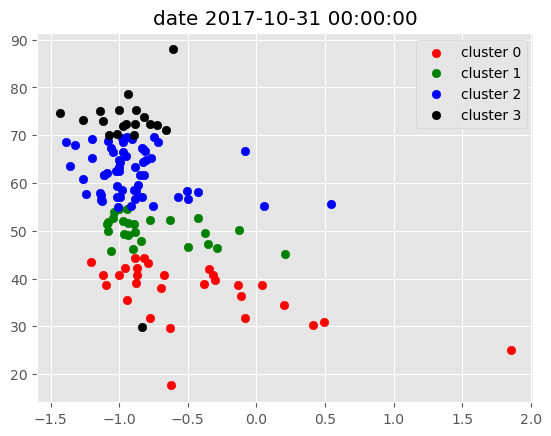

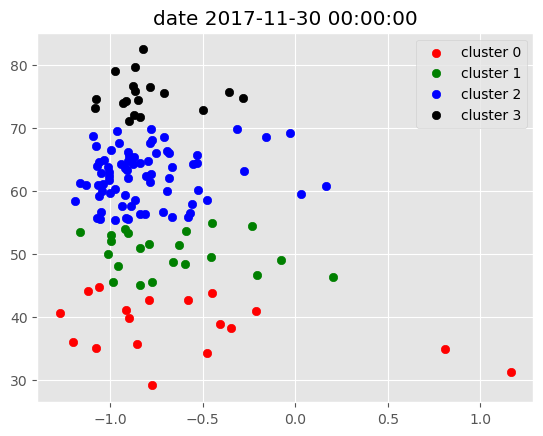

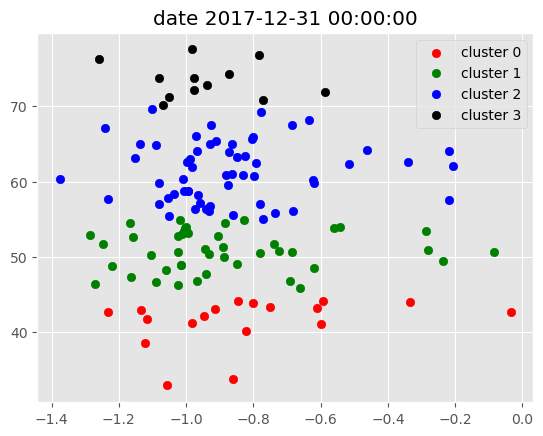

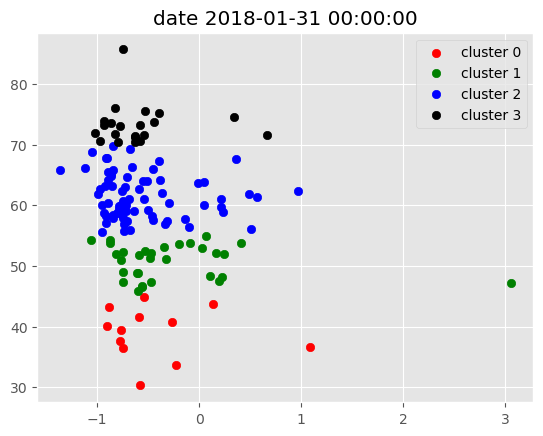

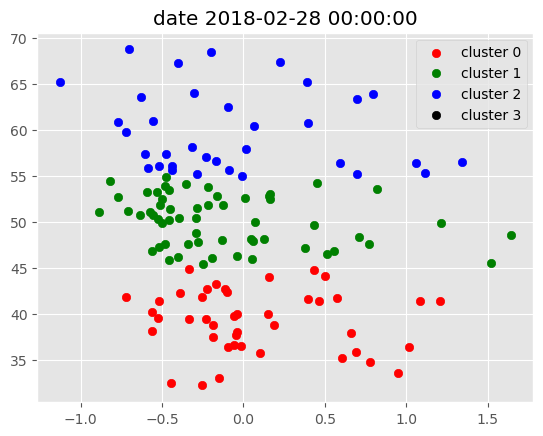

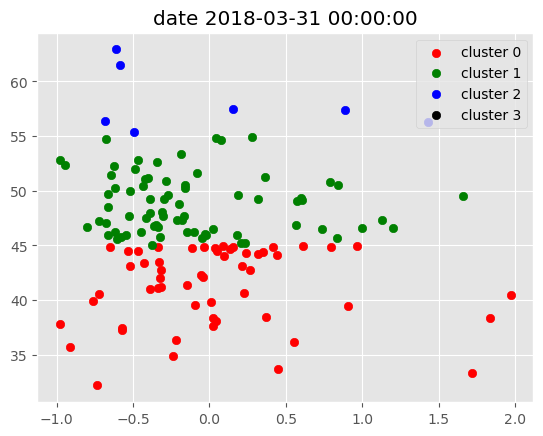

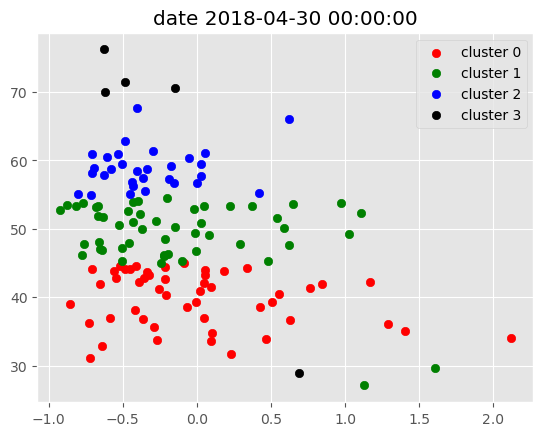

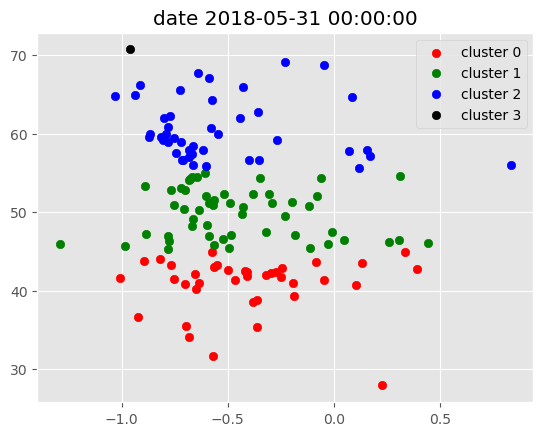

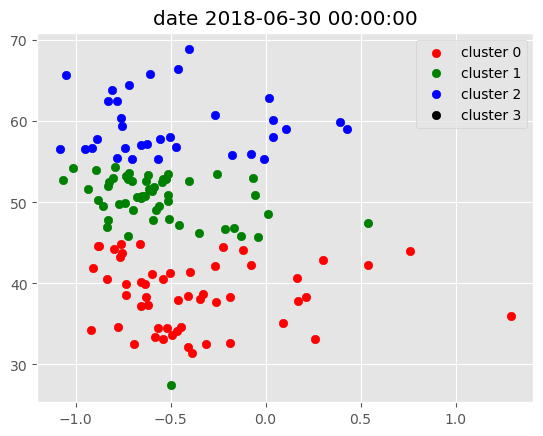

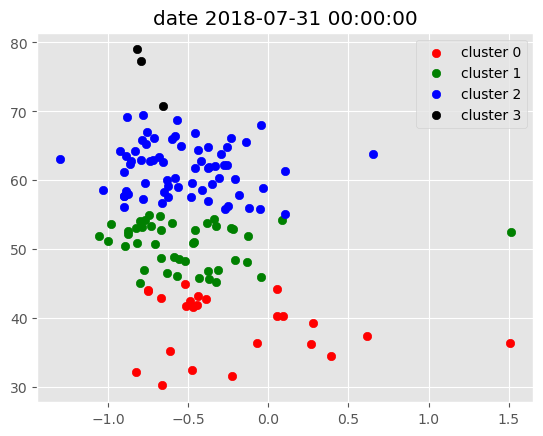

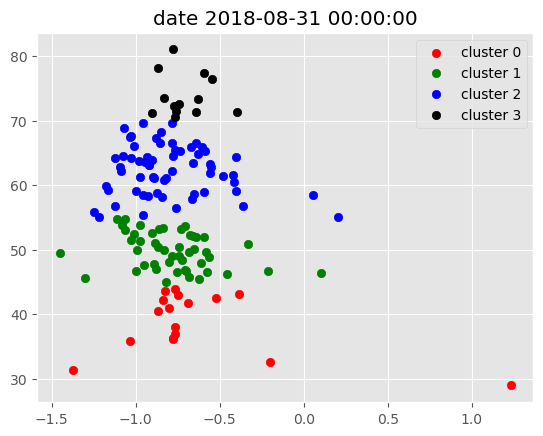

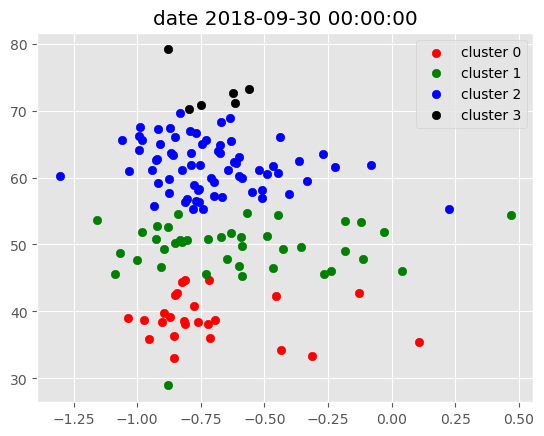

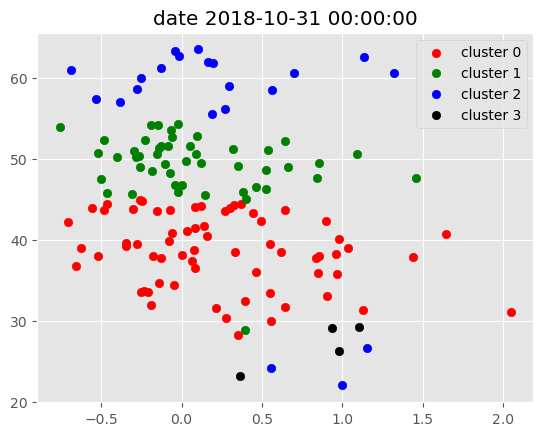

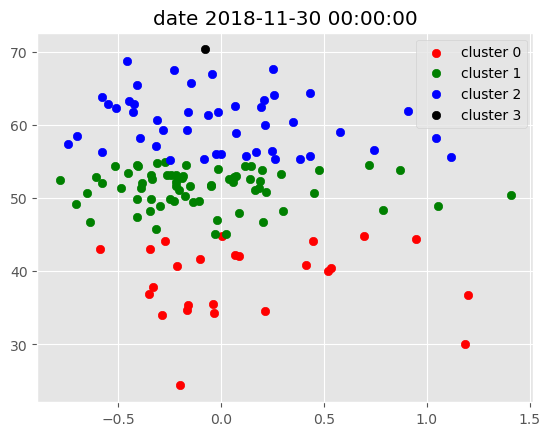

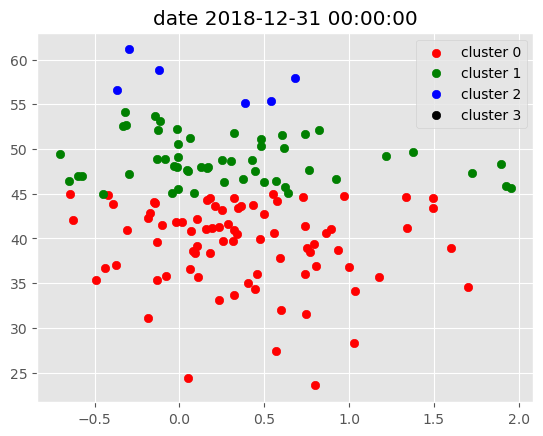

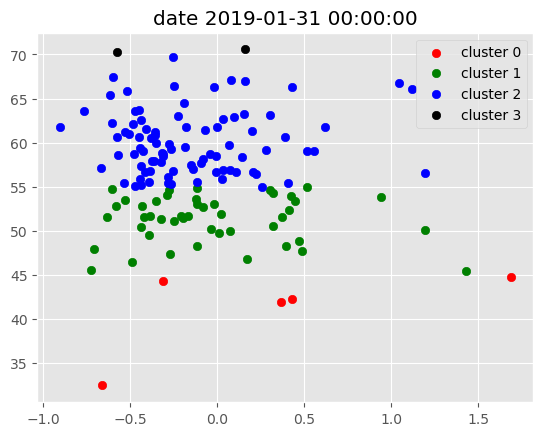

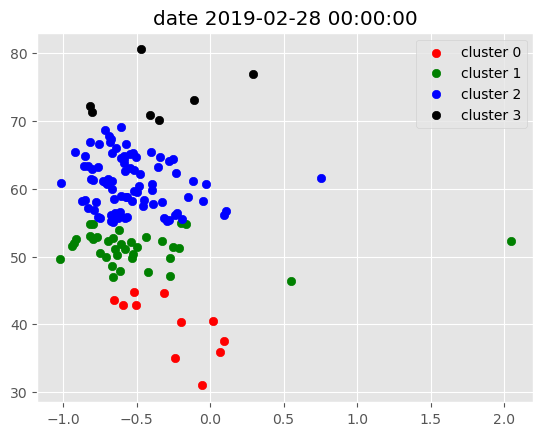

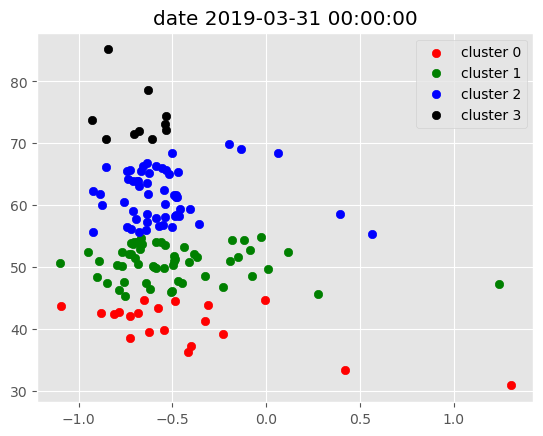

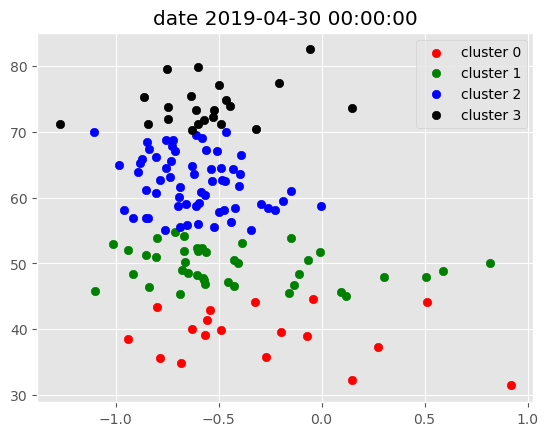

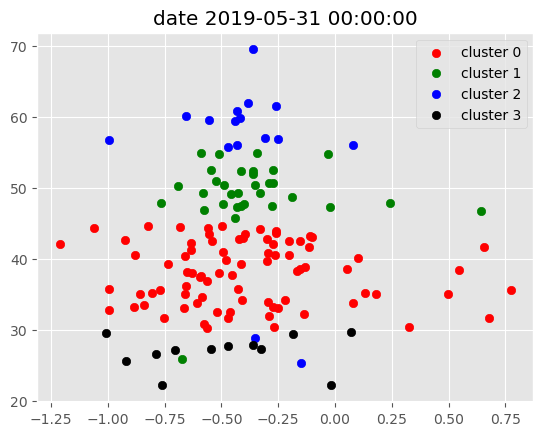

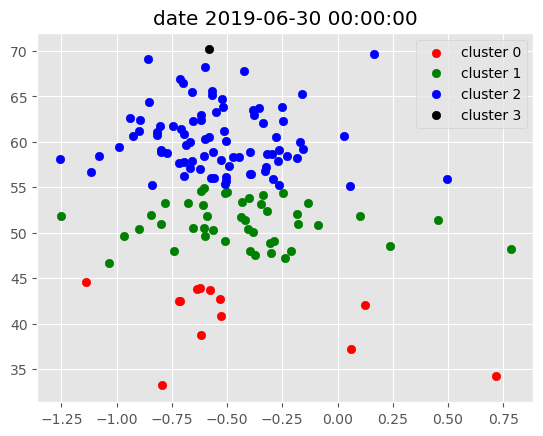

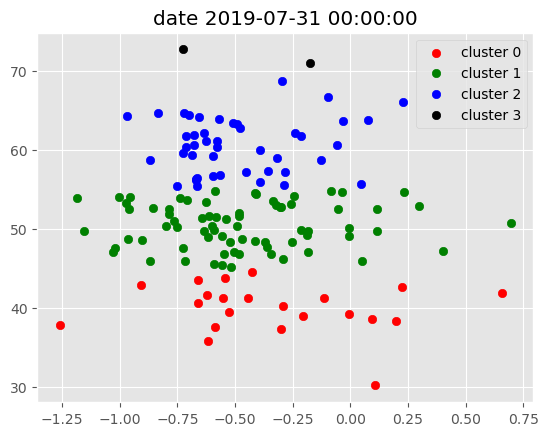

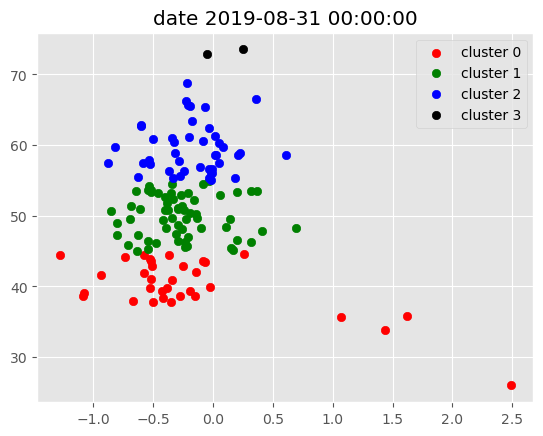

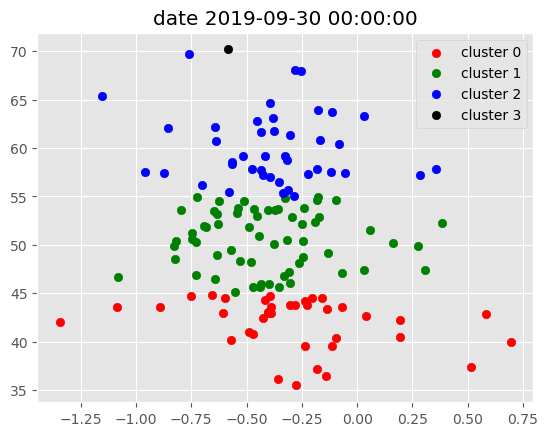

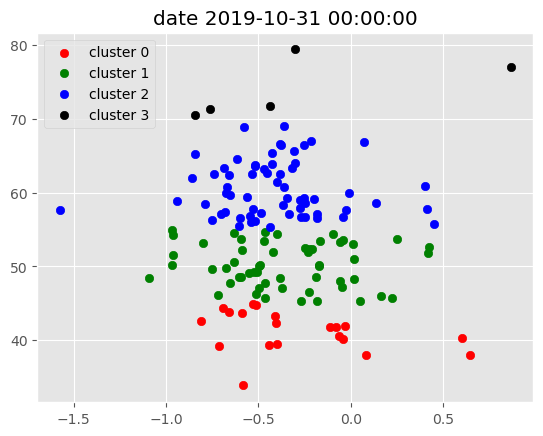

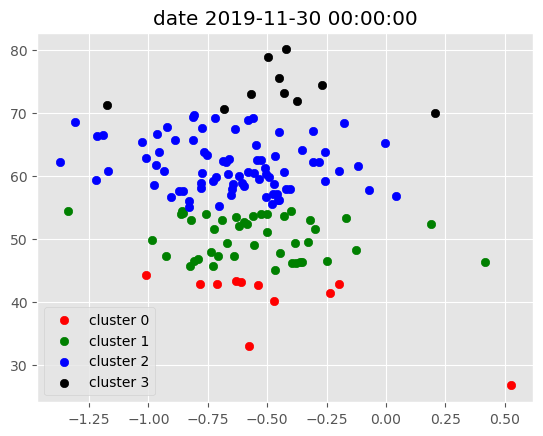

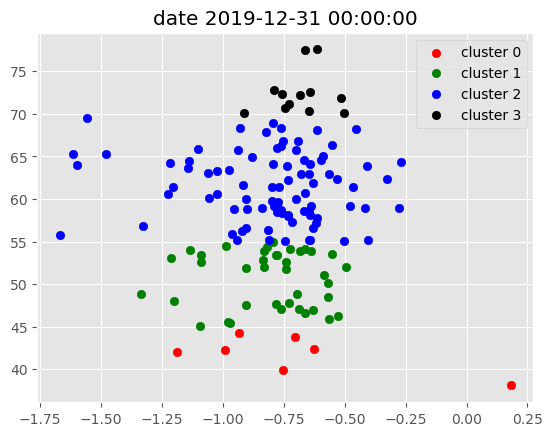

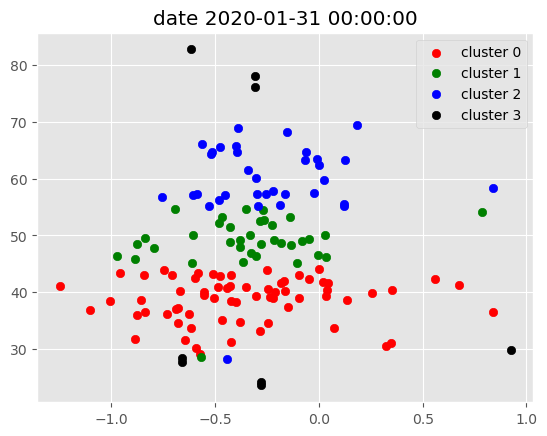

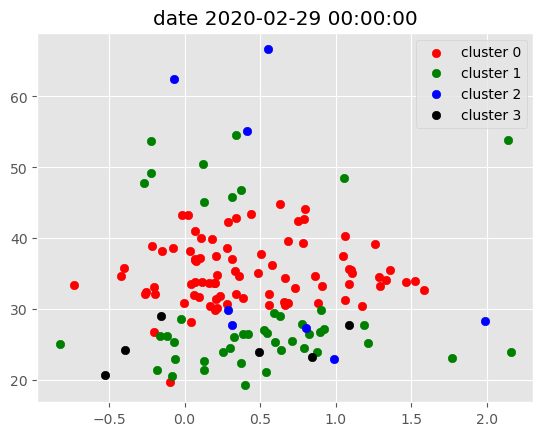

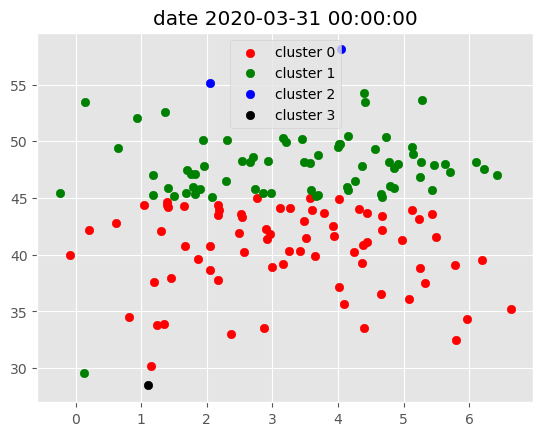

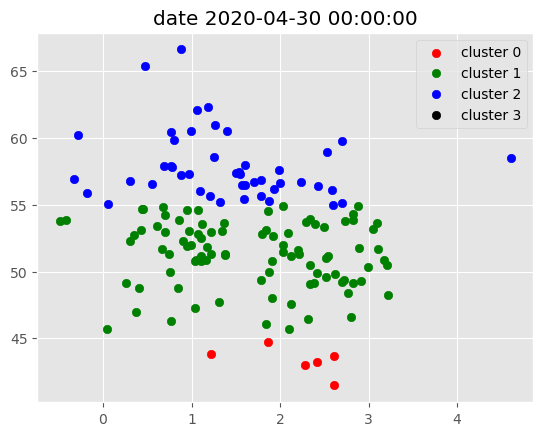

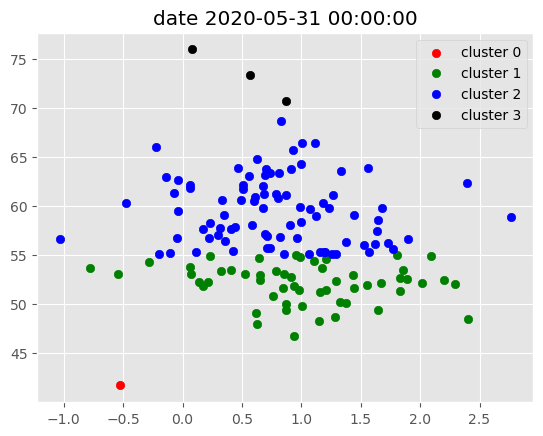

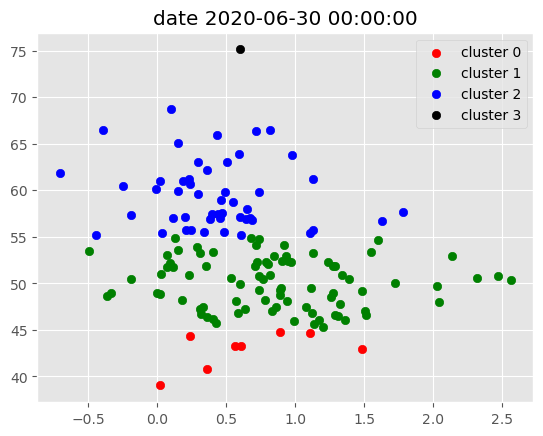

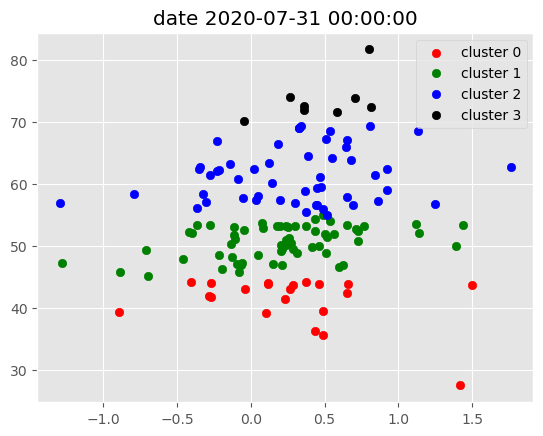

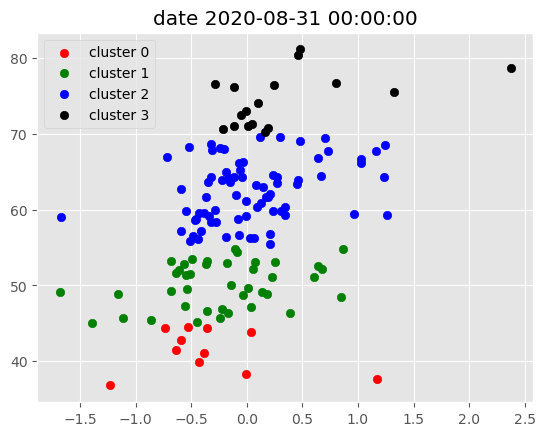

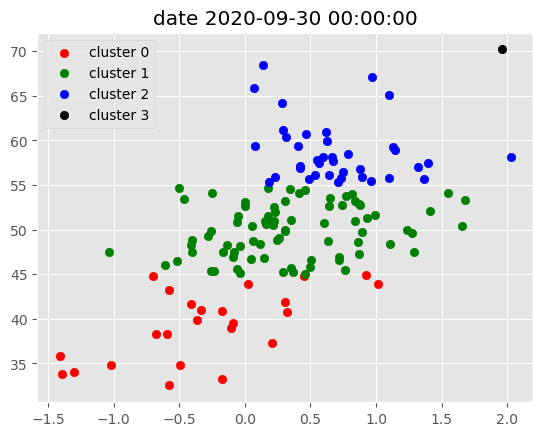

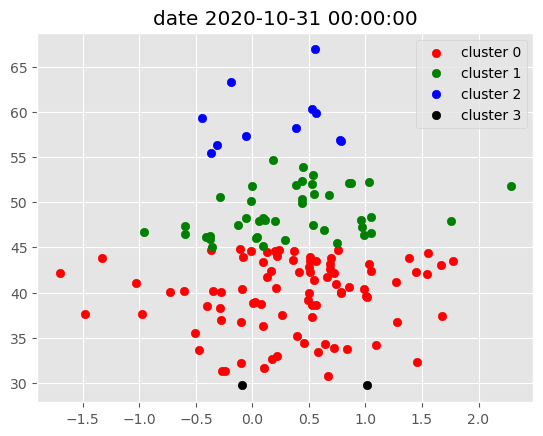

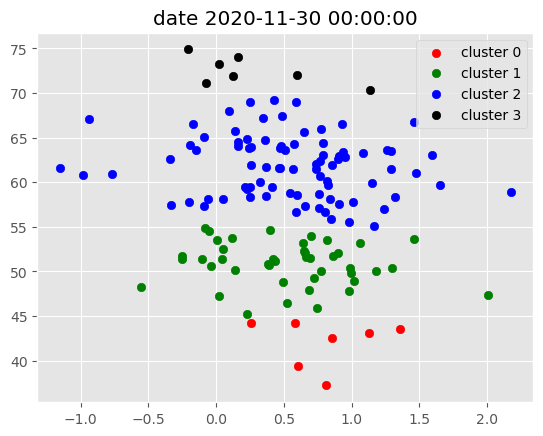

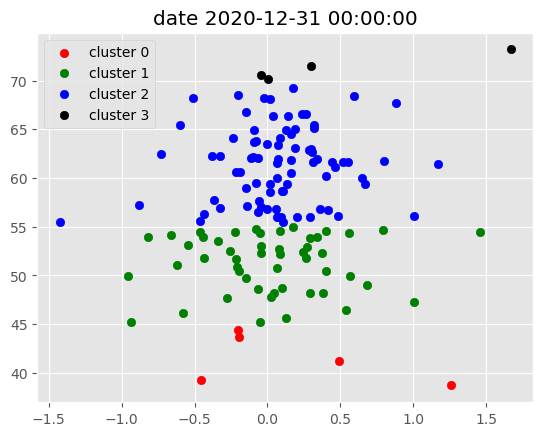

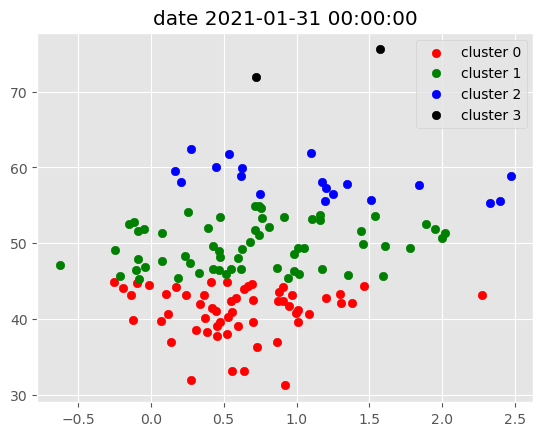

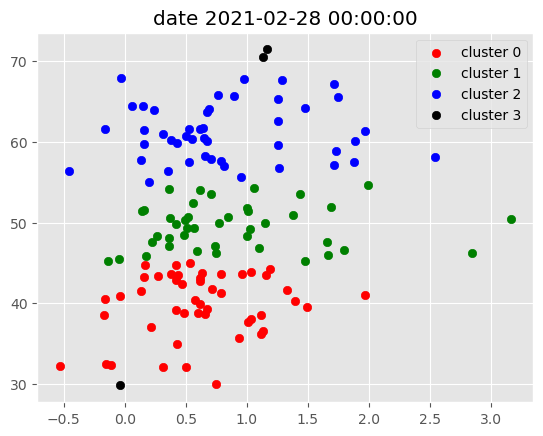

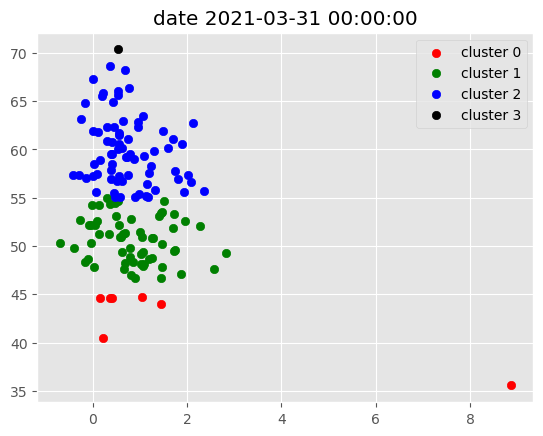

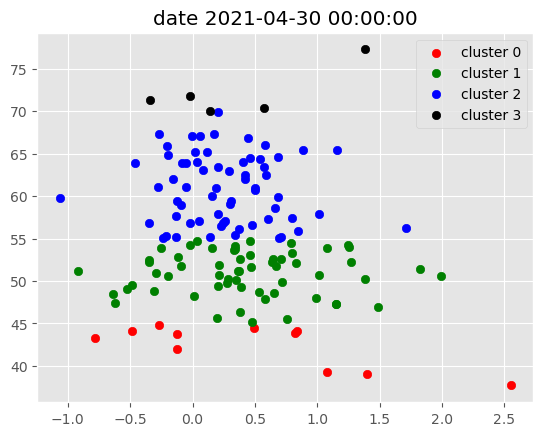

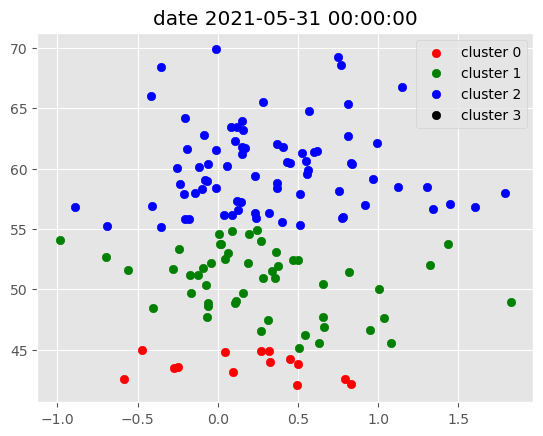

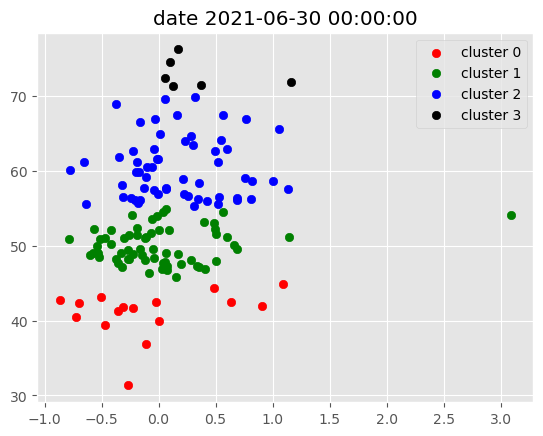

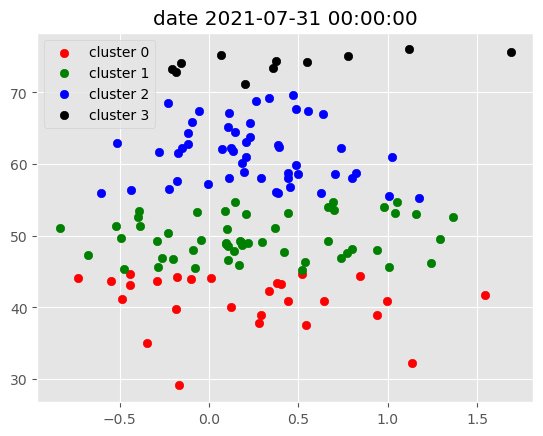

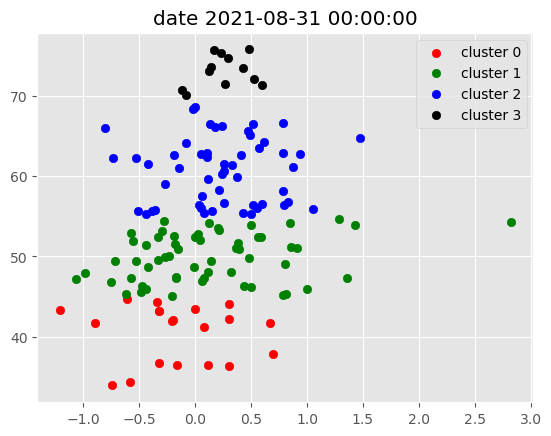

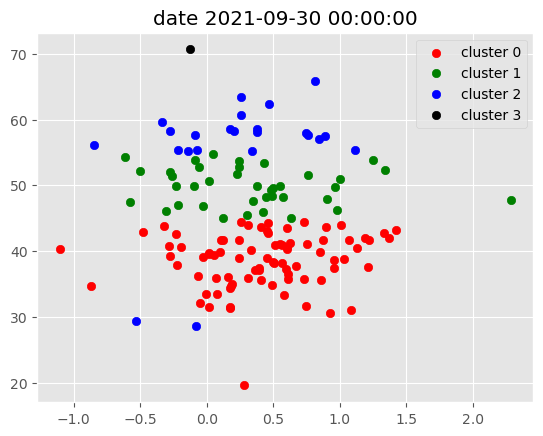

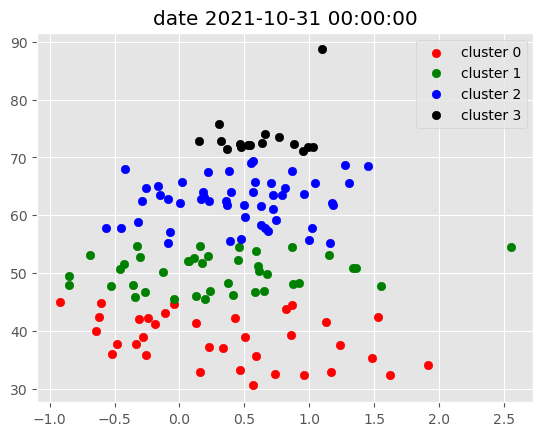

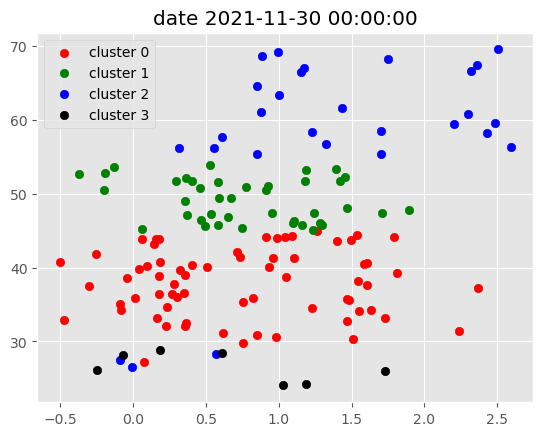

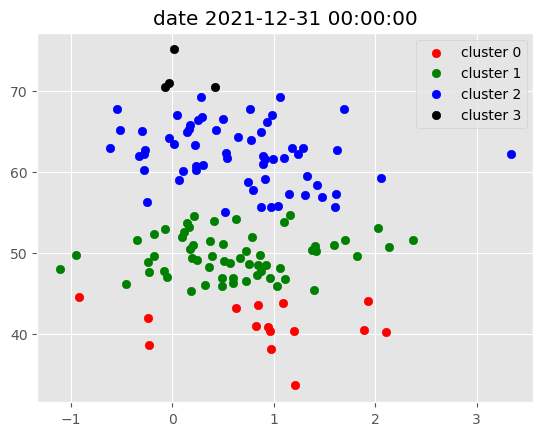

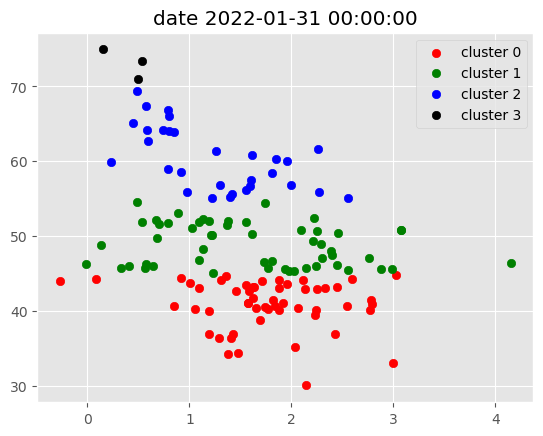

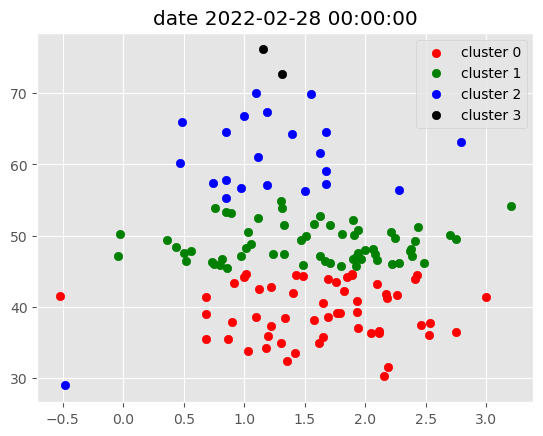

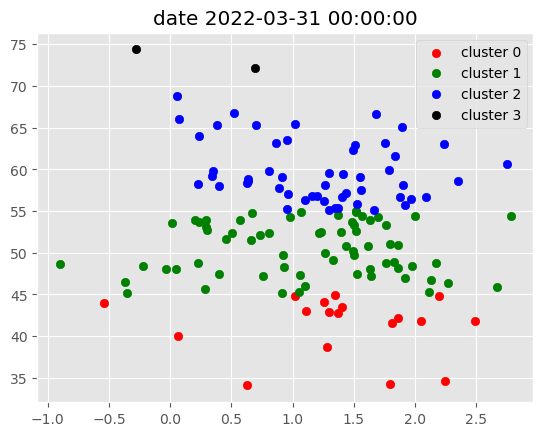

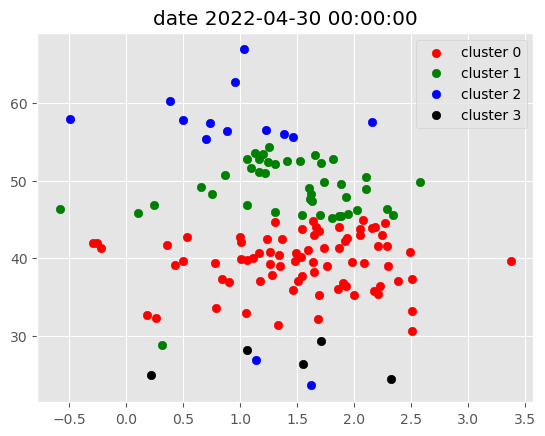

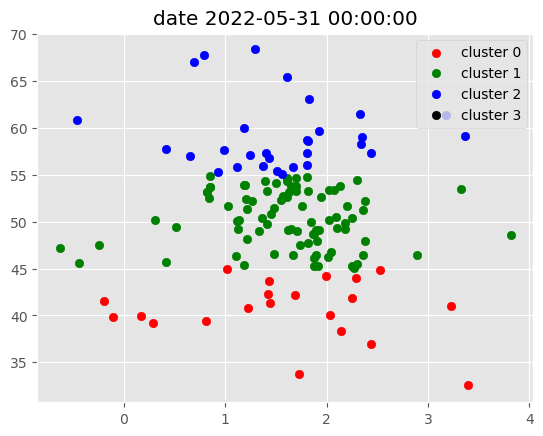

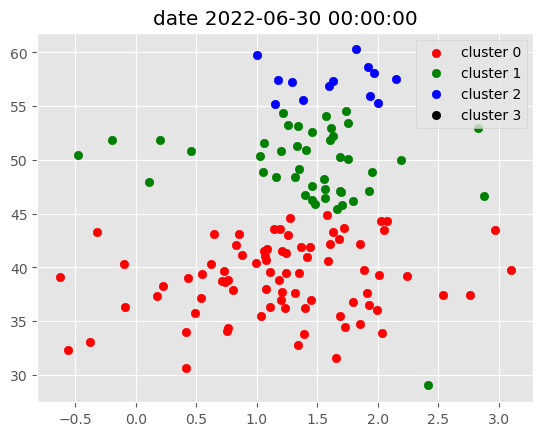

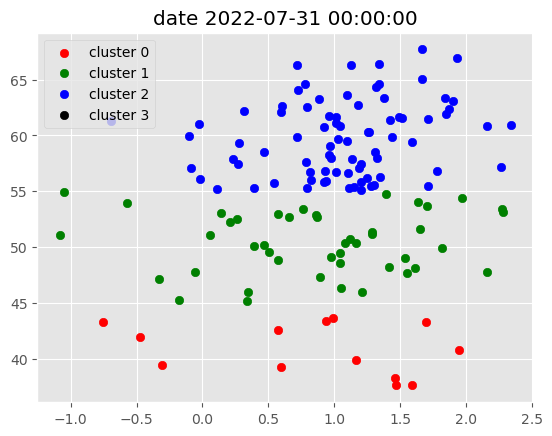

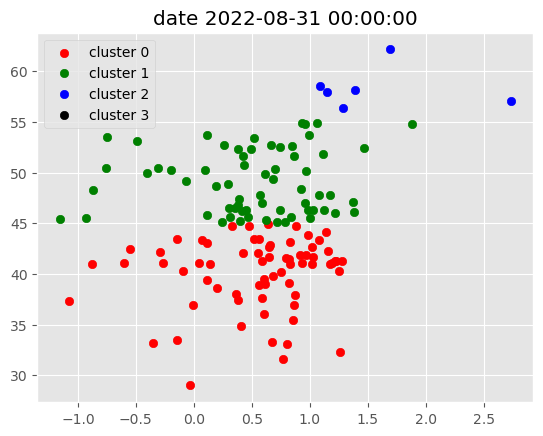

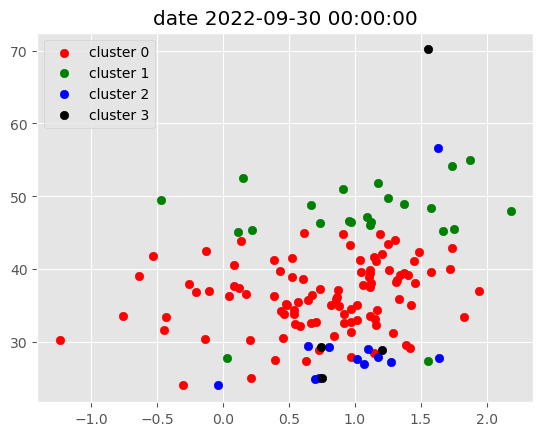

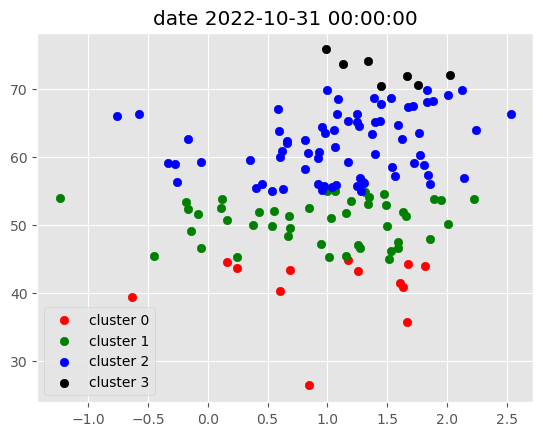

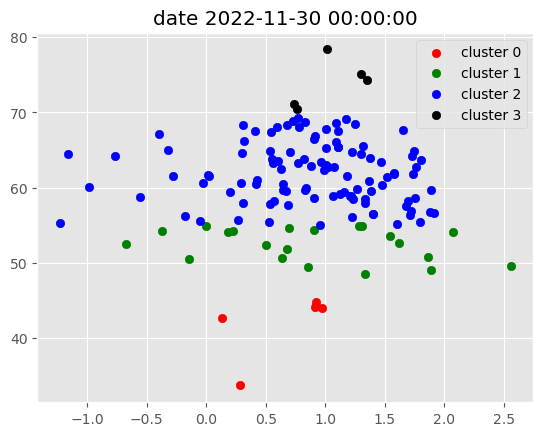

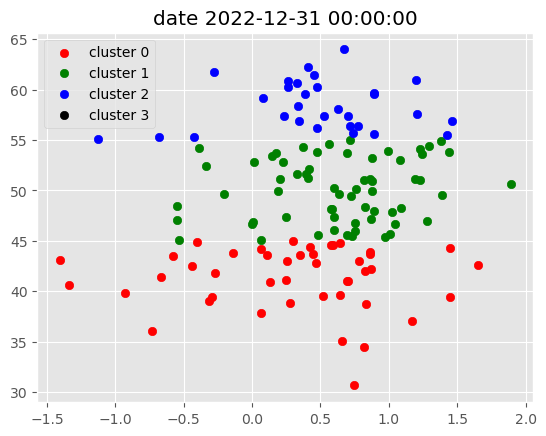

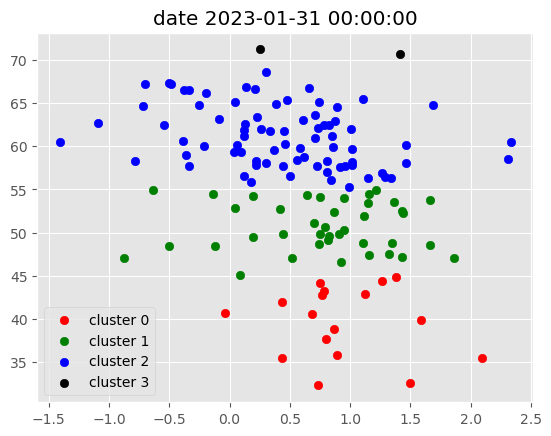

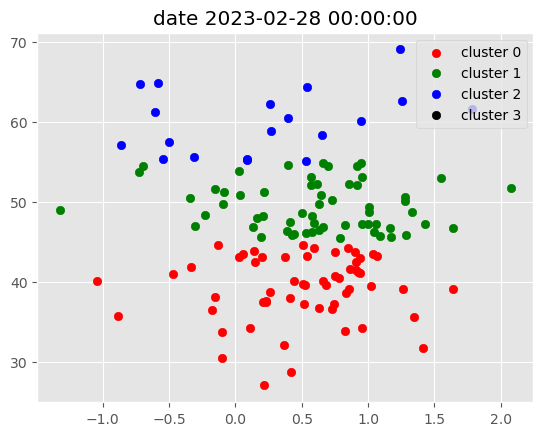

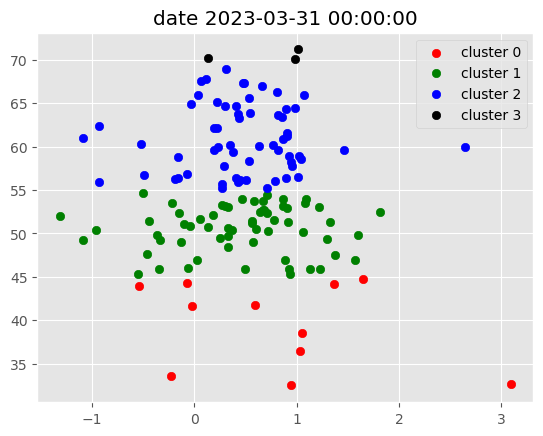

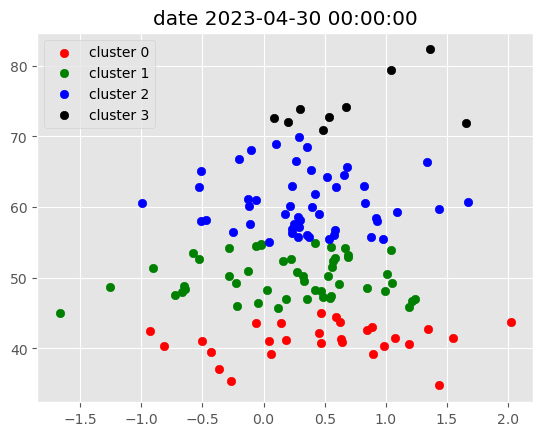

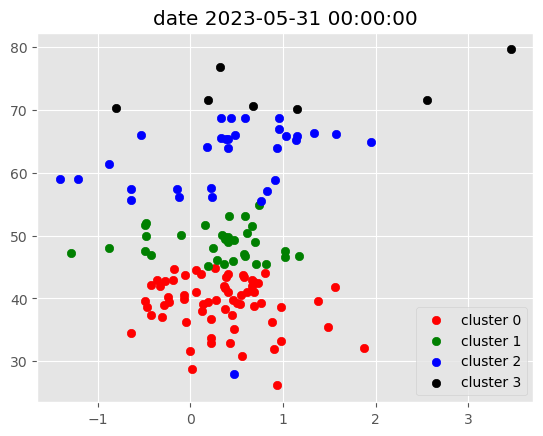

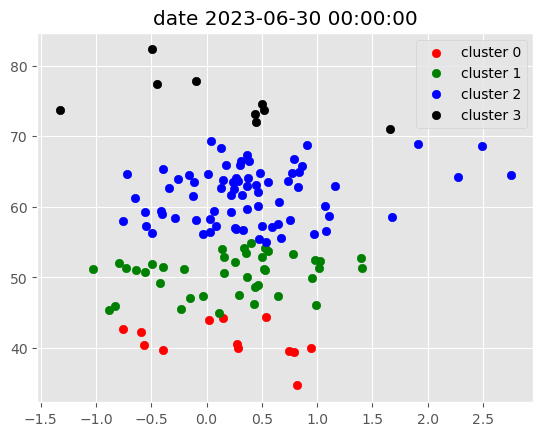

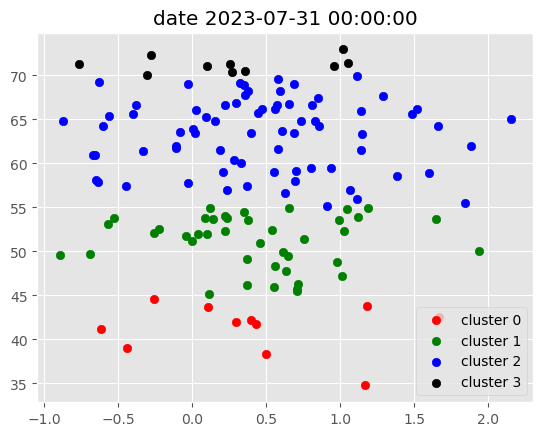

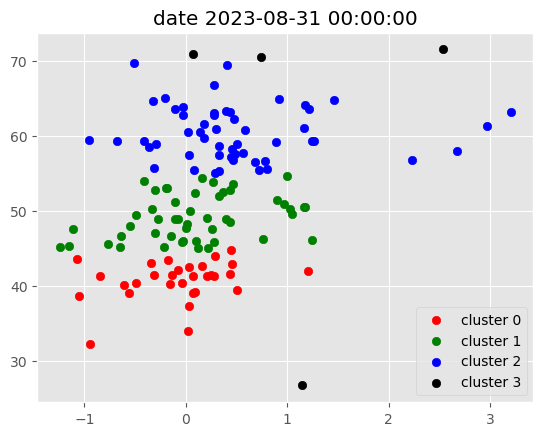

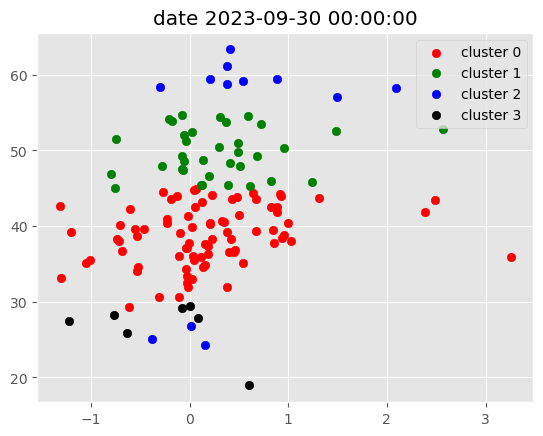

In [365]:
plt.style.use('ggplot')

for i in data.index.get_level_values('date').unique().tolist():

    g = data.xs(i, level=0)

    plt.title(f'date {i}')

    plot_clusters(g)

#### Apply pre-defined centroids

In [360]:
#target_rsi_values = [30, 45, 55, 70]

#initial_centroids = np.zeros((len(target_rsi_values), 18))

#initial_centroids[:, 1] = target_rsi_values

#initial_centroids

array([[ 0., 30.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0., 45.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0., 55.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0., 70.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.]])

## 7. For each month select assets based on the cluster and form a portfolio based on efficient frontier max sharpe ratio optimization

- First we will filter only stocks corresponding to the cluster we choose based on our hypothesis.
- Momentum is persistent and my idea would be that stocks clustered around 70 centroid should continue to outperform in the following month - thus I would selet stocks corresponding to cluster 3.

In [381]:
filtered_df = data[data['cluster']==3].copy()

filtered_df = filtered_df.reset_index(level=1)

filtered_df.index = filtered_df.index+pd.DateOffset(1)

filtered_df

,ticker,garman_klass_vol,rsi,bb_low,bb_mid,bb_high,atr,macd,return_1m,return_2m,return_3m,return_6m,return_9m,return_12m,Mkt-RF,SMB,HML,RMW,CMA,cluster
date,,,,,,,,,,,,,,,,,,,,
2017-11-01,ADBE,0.000067,70.089317,-10.658414,74.980074,160.618562,-0.888660,0.611161,0.174152,0.062497,0.061392,0.045993,0.049515,0.041515,1.109886,-0.318659,-0.184164,-0.218481,-0.687864,3
2017-11-01,AMZN,0.000032,72.442245,-27.056915,76.016499,179.089914,-0.886769,0.351435,0.149717,0.061672,0.038175,0.030123,0.033242,0.028400,1.308769,-0.586467,-0.467615,-0.567622,-0.152936,3
2017-11-01,AXP,0.000053,72.437107,-16.473123,70.010434,156.493990,-0.953262,0.544192,0.060013,0.055315,0.040060,0.032922,0.026493,0.032114,1.235640,-0.372244,0.719467,-0.843603,-0.360696,3
2017-11-01,CAT,0.000054,73.040112,-632.049264,174.490477,981.030219,-1.119478,0.780356,0.095421,0.078303,0.062322,0.050711,0.042176,0.043981,0.950792,0.359421,0.392930,-0.070478,0.152622,3
2017-11-01,CRM,0.000071,73.251088,-22.319368,69.579601,161.478570,-1.260773,0.302331,0.095483,0.035246,0.040686,0.029177,0.029034,0.026057,1.003860,-0.295804,-0.134023,0.115304,-1.042471,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-10-01,DAL,0.000295,28.236918,-44.097414,89.189139,222.475693,-0.769386,-1.264975,-0.142491,-0.108453,-0.081424,0.008994,0.012806,0.022963,1.314927,1.185330,0.638389,-0.180349,0.272266,3
2023-10-01,DG,0.000183,18.941189,-63.174475,85.635344,234.445162,0.597561,-4.237881,-0.213015,-0.173387,-0.133022,-0.092335,-0.079492,-0.056611,0.048437,1.111086,-1.464555,0.499432,1.954021,3
2023-10-01,UAL,0.000205,27.433175,-94.505809,139.584432,373.674672,-1.225630,-1.075996,-0.143746,-0.113825,-0.080550,-0.006119,0.013802,0.022829,1.340809,1.844132,0.368582,-0.359669,0.575972,3


In [387]:
# First, create the proper MultiIndex structure
filtered_df = filtered_df.reset_index().set_index(['date', 'ticker'])

filtered_df

garman_klass_vol        rsi      bb_low      bb_mid  \
date       ticker                                                        
2017-11-01 ADBE            0.000067  70.089317  -10.658414   74.980074   
           AMZN            0.000032  72.442245  -27.056915   76.016499   
           AXP             0.000053  72.437107  -16.473123   70.010434   
           CAT             0.000054  73.040112 -632.049264  174.490477   
           CRM             0.000071  73.251088  -22.319368   69.579601   
...                             ...        ...         ...         ...   
2023-10-01 DAL             0.000295  28.236918  -44.097414   89.189139   
           DG              0.000183  18.941189  -63.174475   85.635344   
           UAL             0.000205  27.433175  -94.505809  139.584432   
           UPS             0.000084  27.924873  -98.350206  154.505835   
           XYZ             0.000338  25.939817  -82.175338  103.455415   

                      bb_high       atr      macd  return_1m  return_2m  \
date       ticker                                                         
2017-11-01 ADBE    160.618562 -0.888660  0.611161   0.174152   0.062497   
           AMZN    179.089914 -0.886769  0.351435   0.149717   0.061672   
           AXP     156.493990 -0.953262  0.544192   0.060013   0.055315   
           CAT     981.030219 -1.119478  0.780356   0.095421   0.078303   
           CRM     161.478570 -1.260773  0.302331   0.095483   0.035246   
...                       ...       ...       ...        ...        ...   
2023-10-01 DAL     222.475693 -0.769386 -1.264975  -0.142491  -0.108453   
           DG      234.445162  0.597561 -4.237881  -0.213015  -0.173387   
           UAL     373.674672 -1.225630 -1.075996  -0.143746  -0.113825   
           UPS     407.361877  0.082474 -1.982414  -0.103306  -0.094963   
           XYZ     289.086169 -0.637639 -0.988286  -0.222723  -0.247423   

                   return_3m  return_6m  return_9m  return_12m    Mkt-RF  \
date       ticker                                                          
2017-11-01 ADBE     0.061392   0.045993   0.049515    0.041515  1.109886   
           AMZN     0.038175   0.030123   0.033242    0.028400  1.308769   
           AXP      0.040060   0.032922   0.026493    0.032114  1.235640   
           CAT      0.062322   0.050711   0.042176    0.043981  0.950792   
           CRM      0.040686   0.029177   0.029034    0.026057  1.003860   
...                      ...        ...        ...         ...       ...   
2023-10-01 DAL     -0.081424   0.008994   0.012806    0.022963  1.314927   
           DG      -0.133022  -0.092335  -0.079492   -0.056611  0.048437   
           UAL     -0.080550  -0.006119   0.013802    0.022829  1.340809   
           UPS     -0.050841  -0.036966  -0.011880   -0.002070  1.218978   
           XYZ     -0.123607  -0.068630  -0.036876   -0.016915  2.425981   

                        SMB       HML       RMW       CMA  cluster  
date       ticker                                                   
2017-11-01 ADBE   -0.318659 -0.184164 -0.218481 -0.687864        3  
           AMZN   -0.586467 -0.467615 -0.567622 -0.152936        3  
           AXP    -0.372244  0.719467 -0.843603 -0.360696        3  
           CAT     0.359421  0.392930 -0.070478  0.152622        3  
           CRM    -0.295804 -0.134023  0.115304 -1.042471        3  
...                     ...       ...       ...       ...      ...  
2023-10-01 DAL     1.185330  0.638389 -0.180349  0.272266        3  
           DG      1.111086 -1.464555  0.499432  1.954021        3  
           UAL     1.844132  0.368582 -0.359669  0.575972        3  
           UPS     0.082129 -0.151866 -0.044797  0.237788        3  
           XYZ     1.933361 -0.378875 -1.635167  0.503283        3  

[394 rows x 19 columns]

In [388]:
dates = filtered_df.index.get_level_values('date').unique().tolist()

# Then your original code should work
fixed_dates = {}
for d in dates:
    fixed_dates[d.strftime('%Y-%m-%d')] = filtered_df.xs(d, level=0).index.tolist()

fixed_dates

{'2017-11-01': ['ADBE',
  'AMZN',
  'AXP',
  'CAT',
  'CRM',
  'DE',
  'INTC',
  'LRCX',
  'MA',
  'MAR',
  'MSFT',
  'MU',
  'NVDA',
  'NXPI',
  'PYPL',
  'REGN',
  'SHW',
  'STZ',
  'TXN'],
 '2017-12-01': ['AZO',
  'BA',
  'BLK',
  'COST',
  'CSCO',
  'DE',
  'DLTR',
  'ELV',
  'HD',
  'HON',
  'KR',
  'MAR',
  'MMM',
  'NKE',
  'SCHW',
  'UNH',
  'UNP',
  'VLO'],
 '2018-01-01': ['CAT',
  'CVX',
  'DE',
  'FCX',
  'HAL',
  'HD',
  'LOW',
  'LUV',
  'MAR',
  'OXY',
  'RTX',
  'VLO'],
 '2018-02-01': ['AMZN',
  'BA',
  'BAC',
  'BRK-B',
  'EA',
  'GOOG',
  'GOOGL',
  'JPM',
  'LMT',
  'LOW',
  'MA',
  'MAR',
  'MSFT',
  'NFLX',
  'NOC',
  'NVDA',
  'PNC',
  'PYPL',
  'RTX',
  'TMO',
  'WFC'],
 '2018-05-01': ['BMY', 'CMG', 'OXY', 'ULTA', 'VLO'],
 '2018-06-01': ['AMD'],
 '2018-08-01': ['KO', 'LLY', 'PFE'],
 '2018-09-01': ['AAPL',
  'ADP',
  'AMD',
  'AMZN',
  'COST',
  'CSCO',
  'ISRG',
  'LLY',
  'LOW',
  'MDT',
  'ORLY',
  'TJX',
  'UAL'],
 '2018-10-01': ['ABT', 'ADP', 'BSX', 'CI', 'PFE

## Define Portfolio Optimization function

- We will define a function which optimizes portfolio weights using PyPortfolioOpt package and EfficientFrontier optimizer to maximize the sharpe ratio
- To optimize the weights of a given porfolio we would need to supply last 1 year prices to the function
- Apply single stock weights bounds constraint for diversification (minimum half of equaly weight and maximum 10% of portfolio)

In [390]:
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns

In [454]:
def optimize_weights(prices, lower_bound=0):

    returns = expected_returns.mean_historical_return(prices=prices, 
                                                      frequency=252)

    cov = risk_models.sample_cov(prices=prices,
                                 frequency=252)

    ef = EfficientFrontier(expected_returns=returns,
                          cov_matrix=cov,
                          weight_bounds=(lower_bound,.1),
                          solver='SCS')

    weights = ef.max_sharpe()

    return ef.clean_weights()
    

Download fresh daily prices data only for short lister stocks

In [405]:
stocks = data.index.get_level_values('ticker').unique().tolist()

new_df = yf.download(tickers=stocks, 
                     start=data.index.get_level_values('date').unique()[0]-pd.DateOffset(months=12),
                    end=data.index.get_level_values('date').unique()[-1]
                    )

[*********************100%***********************]  155 of 155 completed

1 Failed download:
['LRCX']: TypeError("'NoneType' object is not subscriptable")


In [402]:
date = (data.index.get_level_values('date').unique()[0] - pd.DateOffset(months=12))
date

Timestamp('2016-10-31 00:00:00')

In [404]:
data.index.get_level_values('date').unique()[-1]

Timestamp('2023-09-30 00:00:00')

In [417]:
new_df = new_df.drop('Adj Close', axis=1)
new_df

Price            Close                                                 \
Ticker            AAPL        ABBV        ABT         ACN        ADBE   
Date                                                                    
2016-10-31   26.011307   37.921143  33.153141  101.253761  107.510002   
2016-11-01   25.541653   38.376629  32.992619  101.166656  106.870003   
2016-11-02   25.564571   38.607780  32.696915  103.318222  105.889999   
2016-11-03   25.290550   37.995930  32.426540  101.872223  107.169998   
2016-11-04   25.062582   38.097912  33.026413  102.116127  106.199997   
...                ...         ...        ...         ...         ...   
2023-09-25  174.040283  141.587814  92.799469  306.313019  511.600006   
2023-09-26  169.968048  140.910324  91.618889  300.147919  506.299988   
2023-09-27  168.455750  140.196198  90.952408  303.790955  502.600006   
2023-09-28  168.712753  139.390533  93.418320  290.639313  504.670013   
2023-09-29  169.226730  136.469955  92.209167  296.765808  509.899994   

Price                                                                  ...  \
Ticker             ADP        ADSK        AIG        AMAT         AMD  ...   
Date                                                                   ...   
2016-10-31   71.496872   72.279999  48.865028   26.197887    7.230000  ...   
2016-11-01   71.381905   70.099998  48.057205   26.035723    7.090000  ...   
2016-11-02   73.894890   68.680000  47.954254   25.756451    6.760000  ...   
2016-11-03   73.361099   67.610001  46.053516   25.468161    6.700000  ...   
2016-11-04   73.155792   69.440002  45.443691   25.423115    6.560000  ...   
...                ...         ...        ...         ...         ...  ...   
2023-09-25  228.386383  205.669998  59.234890  133.733948   97.379997  ...   
2023-09-26  225.741165  201.660004  58.405430  131.276413   95.959999  ...   
2023-09-27  230.869919  202.279999  58.167084  132.235916   98.070000  ...   
2023-09-28  231.516937  207.889999  58.424500  135.329865  102.760002  ...   
2023-09-29  228.919266  206.910004  57.776184  135.555069  102.820000  ...   

Price        Volume                                                           \
Ticker          VLO     VRTX        VZ     WDAY      WDC       WFC       WMT   
Date                                                                           
2016-10-31  4969500  1928200  12459400  1147300  4449514  20115900  19167000   
2016-11-01  7816800  2458200  13229400  1091400  5055315  20020200  26515800   
2016-11-02  7317600  2580400  16488200  1127800  5578033  19566600  22935900   
2016-11-03  3855900  2371000  12605100   633300  4223810  14982700  20411700   
2016-11-04  3729900  1902100  14410200   892600  3579509  27391600  21786300   
...             ...      ...       ...      ...      ...       ...       ...   
2023-09-25  3241900   698100  17616900   894200  3553446  10624000  10459500   
2023-09-26  4936800   633600  18841600  1217300  4724565  15219400  14435700   
2023-09-27  3644000   860600  22083500  2338100  3370739  11815500  15711000   
2023-09-28  3587300   578900  18772100  9196300  4342086  12454600  11617200   
2023-09-29  4302200   896800  19787600  4066600  3323376  13124500  18842400   

Price                                    
Ticker         WYNN       XOM       XYZ  
Date                                     
2016-10-31  1341600  16663800   2960600  
2016-11-01  3722300  13050600   8190900  
2016-11-02  2542400  11226100  19503200  
2016-11-03  9050400   8836500   7371500  
2016-11-04  3223800  13877100  13462800  
...             ...       ...       ...  
2023-09-25  1387800  11316000   8841300  
2023-09-26  1454000  11805400  10168200  
2023-09-27  2050000  23976200  11656100  
2023-09-28  1290400  16808100  16585100  
2023-09-29  1326800  18813600  11965300  

[1740 rows x 775 columns]

- Calculate daily returns for each stock which could land up in our portfolio
- Then loop over each month start, select the stocks for the month and claculate their weights for the next month
- If the maximum sharpe ratio optimization fails for a given month, apply equally-weighted weights
- Calculated each day portfolio return

In [485]:
returns_dataframe = np.log(new_df['Close']).diff()

portfolio_df = pd.DataFrame()

In [486]:

optimization_df = new_df['Close']['2016-11-01':'2017-10-30'][fixed_dates['2017-11-01']]

optimization_df = optimization_df.drop('LRCX', axis=1)

optimization_df

Ticker,ADBE,AMZN,AXP,CAT,CRM,DE,INTC,MA,MAR,MSFT,MU,NVDA,NXPI,PYPL,REGN,SHW,STZ,TXN
Date,,,,,,,,,,,,,,,,,,
2016-11-01,106.870003,39.270500,58.367470,66.873795,74.544273,76.260834,27.969921,99.486122,62.879192,53.315628,16.567331,1.697957,88.465324,41.444195,344.224518,73.729599,141.064026,53.375340
2016-11-02,105.889999,38.278000,57.662643,65.954941,74.099670,76.321449,28.034739,98.576210,62.952820,52.985748,16.274626,1.690826,88.003235,41.254627,341.353912,74.296471,141.279800,52.914143
2016-11-03,107.169998,38.351501,57.556934,66.085037,73.250000,76.442665,27.700020,98.367699,63.725933,52.789604,16.216082,1.671154,87.745514,41.094997,333.755249,74.002312,138.146957,52.573475
2016-11-04,106.199997,37.752499,57.715515,66.930717,73.477234,76.234871,27.438782,97.656815,64.066460,52.343826,16.274626,1.661564,87.709946,40.805668,339.099152,74.314850,138.077713,52.341187
2016-11-07,108.660004,39.246498,59.028233,68.101646,75.384071,77.048645,28.320478,100.433983,65.437790,53.868393,16.957607,1.752548,87.727722,41.184792,362.938110,75.978600,143.563110,53.432919
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-10-24,171.580002,48.794998,84.023888,115.796104,97.475647,115.850868,34.174831,139.223755,109.004364,72.002724,40.588985,4.908557,103.785690,70.048065,423.647949,120.478065,185.514832,76.072380
2017-10-25,171.830002,48.645500,83.728462,114.623421,98.394485,115.444107,34.032955,139.643890,108.556450,71.792770,40.062111,4.784534,103.519119,70.856194,419.098724,121.602570,185.366470,75.583344
2017-10-26,173.750000,48.621498,85.662140,114.707191,98.848961,116.841194,34.508644,139.978119,110.870743,71.911461,39.613293,4.834688,103.634621,71.175461,413.248199,122.829369,184.720917,75.843643


In [496]:
for start_date in fixed_dates.keys():

    try: 
        
        end_date = (pd.to_datetime(start_date)+pd.offsets.MonthEnd(0)).strftime('%Y-%m-%d')

        cols = fixed_dates[start_date]

        optimization_start_date = (pd.to_datetime(start_date) - pd.DateOffset(months=12)).strftime('%Y-%m-%d')

        optimization_end_date = (pd.to_datetime(start_date) - pd.DateOffset(days=1)).strftime('%Y-%m-%d')

        optimization_df = new_df['Close'][optimization_start_date:optimization_end_date][cols]

        success = False
        
        try:
            weights = optimize_weights(prices=optimization_df, 
                           lower_bound=round(1/(len(optimization_df.columns)*2),3))

            weights = pd.DataFrame(weights, index=pd.Series(0))

            success = True

        except:
            print(f'Max Sharpe Optimization failed for {start_date}, continuing with equal weights')

        if success == False:
            weights = pd.DataFrame([1/len(optimization_df.columns) for i in range(len(optimization_df.columns))],
                                      index=optimization_df.columns.tolist(),
                                      columns=pd.Series(0)).T
        
        temp_df = returns_dataframe[start_date:end_date]

        temp_df = temp_df.stack().to_frame('return').reset_index(level=0)\
                        .merge(weights.stack().to_frame('weight').reset_index(level=0, drop=True),
                          left_index=True,
                          right_index=True)\
                        .reset_index().set_index(['Date', 'Ticker']).unstack().stack()

        temp_df.index.names = ['date', 'ticker']

        temp_df['weighted_return'] = temp_df['return']*temp_df['weight']

        temp_df = temp_df.groupby(level=0)['weighted_return'].sum().to_frame('Strategy Return')

        portfolio_df = pd.concat([portfolio_df, temp_df], axis=0)

    except Exception as e:

        print(e)

portfolio_df = portfolio_df.drop_duplicates()

portfolio_df

Max Sharpe Optimization failed for 2017-11-01, continuing with equal weights
Max Sharpe Optimization failed for 2018-05-01, continuing with equal weights
Max Sharpe Optimization failed for 2018-06-01, continuing with equal weights
Max Sharpe Optimization failed for 2018-08-01, continuing with equal weights
Max Sharpe Optimization failed for 2018-10-01, continuing with equal weights
Max Sharpe Optimization failed for 2018-11-01, continuing with equal weights
Max Sharpe Optimization failed for 2018-12-01, continuing with equal weights
Max Sharpe Optimization failed for 2019-02-01, continuing with equal weights
Max Sharpe Optimization failed for 2019-03-01, continuing with equal weights
Max Sharpe Optimization failed for 2019-05-01, continuing with equal weights
Max Sharpe Optimization failed for 2019-06-01, continuing with equal weights
Max Sharpe Optimization failed for 2019-07-01, continuing with equal weights
Max Sharpe Optimization failed for 2019-08-01, continuing with equal weights

,Strategy Return
date,
2017-11-01,0.001243
2017-11-02,0.001042
2017-11-03,0.005015
2017-11-06,0.002842
2017-11-07,0.000564
...,...
2023-09-25,-0.000403
2023-09-26,-0.012012
2023-09-27,0.001222


<Axes: xlabel='date'>

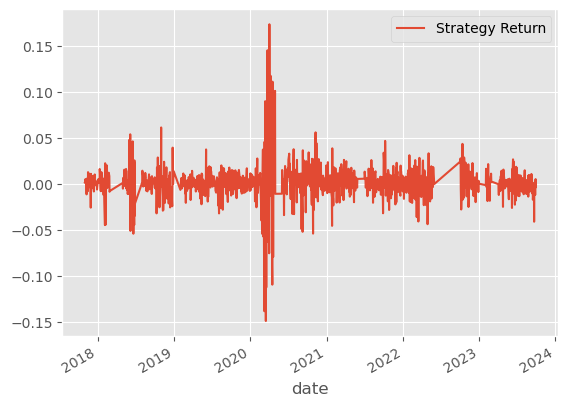

In [497]:
portfolio_df.plot()

## 8. Visualize Porfolio returns and compare to SP500

In [509]:
spy = yf.download(tickers='SPY',
                  start='2015-01-01',
                  end=dt.date.today())

spy_ret = np.log(spy[['Close']]).diff().dropna().rename({'Close': 'SPY Buy and Hold'}, axis=1)


spy_ret = spy_ret.droplevel(level=1, axis=1)

spy_ret

[*********************100%***********************]  1 of 1 completed


Price,SPY Buy and Hold
Date,
2015-01-05,-0.018225
2015-01-06,-0.009464
2015-01-07,0.012384
2015-01-08,0.017589
2015-01-09,-0.008046
...,...
2026-02-13,0.000704
2026-02-17,0.001612
2026-02-18,0.005025


In [510]:
portfolio_df = portfolio_df.merge(spy_ret,
                                  left_index=True,
                                  right_index=True)

portfolio_df

,Strategy Return,SPY Buy and Hold
2017-11-01,0.001243,0.001321
2017-11-02,0.001042,0.000388
2017-11-03,0.005015,0.003333
2017-11-06,0.002842,0.001547
2017-11-07,0.000564,-0.000696
...,...,...
2023-09-25,-0.000403,0.004196
2023-09-26,-0.012012,-0.014800
2023-09-27,0.001222,0.000399
2023-09-28,0.005164,0.005781


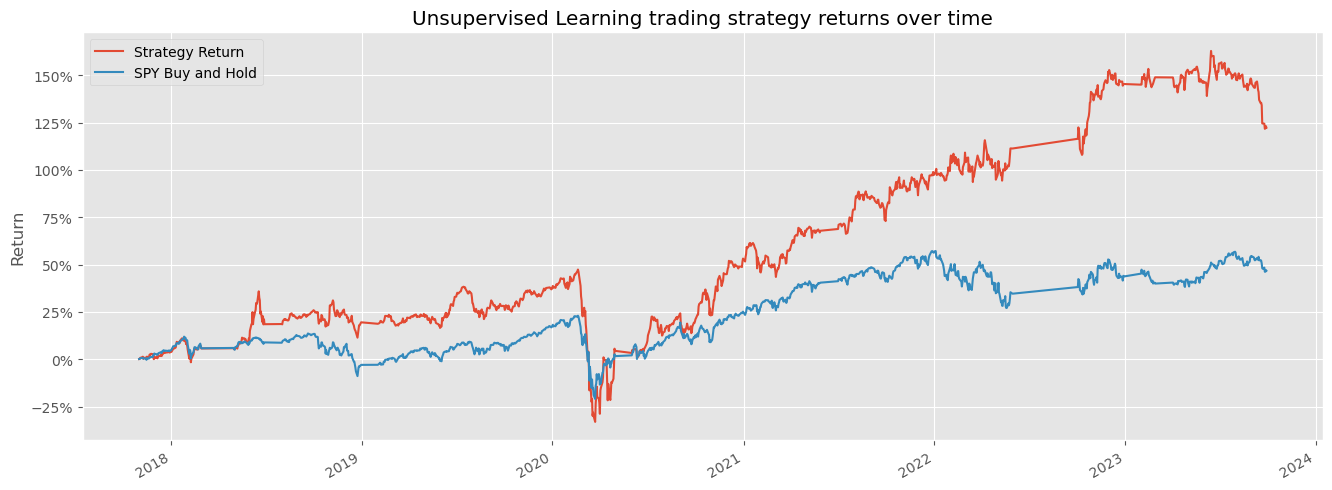

In [514]:
import matplotlib.ticker as mtick

plt.style.use('ggplot')

portfolio_cumulative_return = np.exp(np.log1p(portfolio_df).cumsum())-1

portfolio_cumulative_return.plot(figsize=(16,6))

plt.title('Unsupervised Learning trading strategy returns over time')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.ylabel('Return')

plt.show()

In [515]:
portfolio_cumulative_return

,Strategy Return,SPY Buy and Hold
2017-11-01,0.001243,0.001321
2017-11-02,0.002286,0.001710
2017-11-03,0.007313,0.005049
2017-11-06,0.010175,0.006603
2017-11-07,0.010745,0.005903
...,...,...
2023-09-25,1.244634,0.484244
2023-09-26,1.217672,0.462277
2023-09-27,1.220383,0.462861
2023-09-28,1.231850,0.471317
